# Projet People Analytics — Refonte sur `people_analytics_dataset__v2.csv`

Analyse entièrement recalculée sur le dataset v2 : EDA, KPI RH et Machine Learning.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
ATTRITION_COLORS = {0: '#2E8B57', 1: '#C0392B'}


In [2]:
def load_dataset():
    for path in ['./people_analytics_dataset__v2.csv', '/content/people_analytics_dataset__v2.csv']:
        try:
            data = pd.read_csv(path)
            print(f'✅ Dataset chargé depuis: {path}')
            return data
        except FileNotFoundError:
            continue
    raise FileNotFoundError('people_analytics_dataset__v2.csv introuvable')


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def plot_attrition_rate_by(data, col, top_n=None):
    stats = (
        data.groupby(col)
        .agg(effectif=('attrition', 'size'), taux_attrition=('attrition', 'mean'))
        .sort_values('taux_attrition', ascending=False)
    )
    if top_n is not None:
        stats = stats.head(top_n)
    plt.figure(figsize=(11, 5))
    sns.barplot(data=stats.reset_index(), x=col, y='taux_attrition', hue=col, legend=False, palette='viridis')
    plt.title(f'Taux de turnover par {col}')
    plt.xticks(rotation=35, ha='right')
    plt.ylabel("Taux d'attrition")
    for i, v in enumerate(stats['taux_attrition'].values):
        plt.text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)
    plt.ylim(0, max(0.05, stats['taux_attrition'].max() * 1.15))
    plt.show()
    return stats


df_raw = load_dataset()
df = df_raw.copy()


✅ Dataset chargé depuis: ./people_analytics_dataset__v2.csv


## Partie 1 — EDA

In [3]:
print(f'Dimensions initiales: {df.shape[0]} lignes × {df.shape[1]} colonnes')
display(df.head())
display(df.dtypes.to_frame('dtype'))
display(df.describe().T)
display(df.describe(include='object').T)


Dimensions initiales: 8020 lignes × 28 colonnes


,employee_id,age,gender,country,department,job_role,education_level,school_tier,parental_status,accented_name_flag,...,promotion_last_3y,absenteeism_days,overtime_hours,manager_favoritism_score,visibility_score,psychological_safety_score,salary,bonus,stock_options,attrition
0,EMP_100000,25,Male,Canada,Data,Data Scientist,Master,Tier 2,Parent,0,...,0,15,3,59.4,61.9,52.1,59751.0,543,4396,0
1,EMP_100001,33,Female,Germany,Sales,Sales Executive,Bachelor,Tier 3,Parent,1,...,0,27,3,58.1,50.6,39.7,58502.0,6895,514,0
2,EMP_100002,34,Male,France,HR,Talent Manager,Master,Tier 2,No Children,0,...,0,25,3,76.0,64.8,44.8,57278.0,1887,2504,0
3,EMP_100003,38,Male,France,Data,Data Engineer,Master,Tier 2,No Children,0,...,0,20,25,79.8,54.6,33.2,72989.0,8585,986,1
4,EMP_100004,36,Male,Germany,IT,DevOps Engineer,Bachelor,Tier 1,No Children,0,...,1,9,27,38.8,52.5,68.6,81888.0,1530,1782,0


,dtype
employee_id,str
age,int64
gender,str
country,str
department,str
job_role,str
education_level,str
school_tier,str
parental_status,str
accented_name_flag,int64


,count,mean,std,min,25%,50%,75%,max
age,8020.0,35.784539,8.428996,22.0,30.000000,36.000000,42.000000,63.0
accented_name_flag,8020.0,0.199501,0.399650,0.0,0.000000,0.000000,0.000000,1.0
contracted_hours_weekly,8020.0,32.995137,3.164777,28.0,28.000000,35.000000,35.000000,35.0
years_at_company,8020.0,4.986534,4.065595,0.0,1.000000,5.000000,8.000000,24.0
manager_level,8020.0,0.508978,0.801261,0.0,0.000000,0.000000,1.000000,3.0
remote_ratio,8020.0,51.218828,31.220369,0.0,25.000000,50.000000,75.000000,100.0
performance_rating,7859.0,3.452466,0.694766,1.0,2.980000,3.460000,3.930000,5.0
engagement_score,7860.0,67.792353,14.739814,20.0,58.008102,67.754859,78.041524,100.0
training_hours,8020.0,34.471820,17.364725,0.0,22.000000,34.000000,46.000000,96.0
internal_mobility_count,8020.0,0.976434,1.001592,0.0,0.000000,1.000000,2.000000,7.0


,count,unique,top,freq
employee_id,8020,8000,EMP_101123,2
gender,8020,3,Female,3869
country,8020,6,Canada,1356
department,8020,8,Data,1042
job_role,8020,24,Support Agent,542
education_level,8020,3,Master,4332
school_tier,8020,3,Tier 2,4082
parental_status,8020,2,No Children,4370


,missing_count,missing_pct
salary,161,0.020075
performance_rating,161,0.020075
engagement_score,160,0.019950


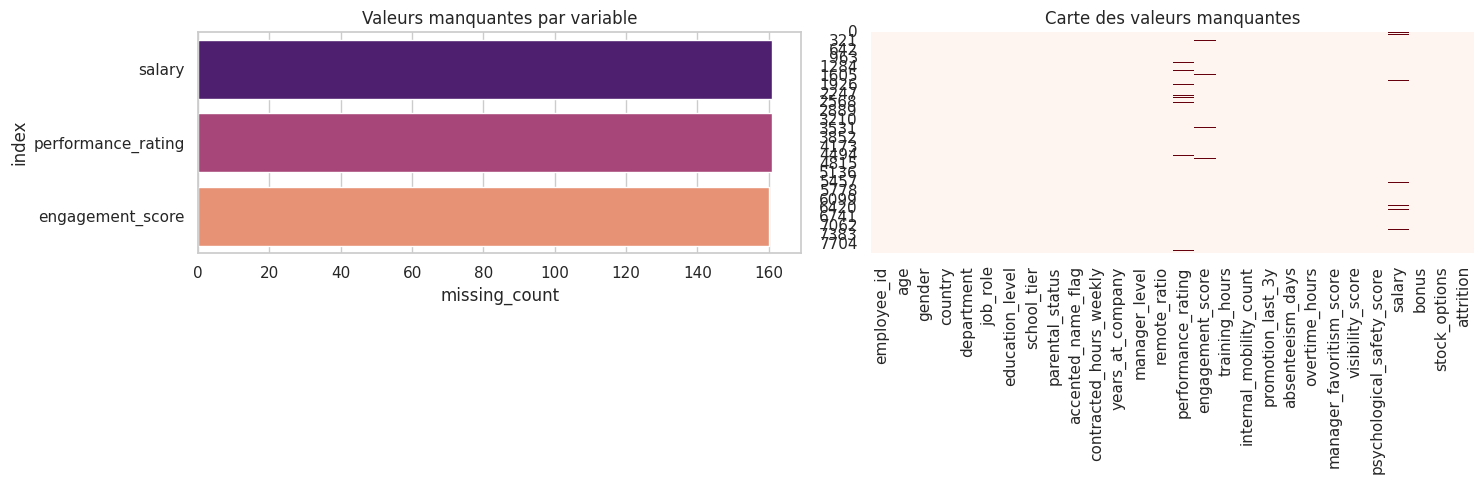

Doublons exacts: 20
Dimensions après drop_duplicates: (8000, 28)


,variable,Q1,Q3,IQR,borne_basse,borne_haute,nb_outliers,pct_outliers
4,stock_options,0.00,5261.25,5261.25,-7891.875,13153.125,312,0.039000
0,salary,51545.75,71302.00,19756.25,21911.375,100936.375,90,0.011250
2,absenteeism_days,8.00,19.00,11.00,-8.500,35.500,72,0.009000
3,bonus,2815.00,7141.00,4326.00,-3674.000,13630.000,25,0.003125
1,overtime_hours,12.00,29.00,17.00,-13.500,54.500,22,0.002750


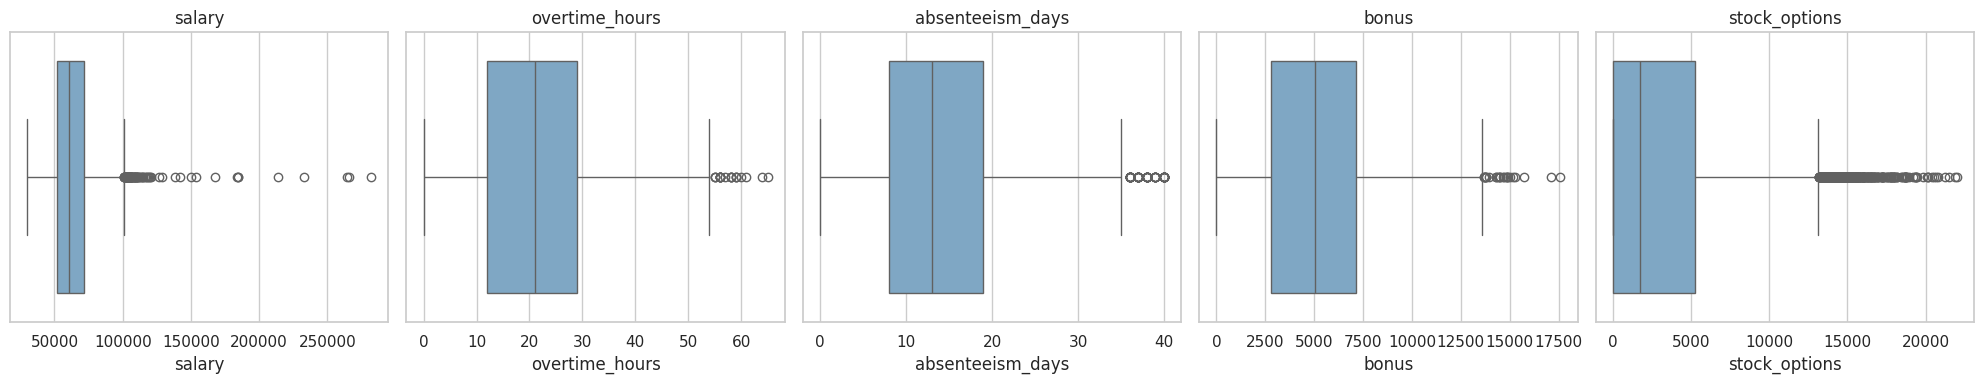

performance_rating    0
engagement_score      0
salary                0
dtype: int64


In [4]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df)).sort_values(ascending=False)
missing_table = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0]
display(missing_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
if len(missing_table):
    sns.barplot(data=missing_table.reset_index(), x='missing_count', y='index', hue='index', legend=False, palette='magma', ax=axes[0])
    axes[0].set_title('Valeurs manquantes par variable')
else:
    axes[0].text(0.5, 0.5, 'Aucune valeur manquante', ha='center', va='center')
    axes[0].set_axis_off()

sns.heatmap(df.isna(), cmap='Reds', cbar=False, ax=axes[1])
axes[1].set_title('Carte des valeurs manquantes')
plt.tight_layout()
plt.show()

duplicates_before = int(df.duplicated().sum())
print('Doublons exacts:', duplicates_before)
df = df.drop_duplicates().copy()
print('Dimensions après drop_duplicates:', df.shape)

outlier_cols = ['salary', 'overtime_hours', 'absenteeism_days', 'bonus', 'stock_options']
outlier_rows = []
for c in outlier_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((df[c] < lower) | (df[c] > upper)).sum())
    outlier_rows.append({'variable': c, 'Q1': q1, 'Q3': q3, 'IQR': iqr, 'borne_basse': lower, 'borne_haute': upper, 'nb_outliers': n, 'pct_outliers': n / len(df)})
outlier_table = pd.DataFrame(outlier_rows).sort_values('pct_outliers', ascending=False)
display(outlier_table)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, c in zip(axes, outlier_cols):
    sns.boxplot(data=df, x=c, color='#74A9CF', ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

for c in ['performance_rating', 'engagement_score', 'salary']:
    df[c] = df[c].fillna(df[c].median())
print(df[['performance_rating', 'engagement_score', 'salary']].isna().sum())


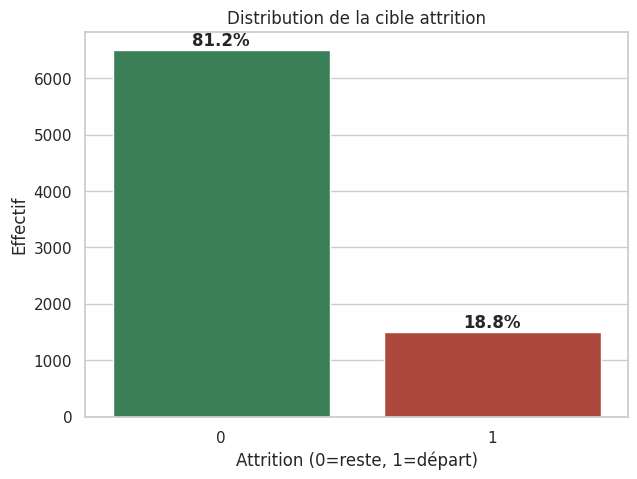

,effectif,proportion
attrition,,
0,6498,0.81225
1,1502,0.18775


In [5]:
attrition_dist = df['attrition'].value_counts().sort_index()
attrition_pct = df['attrition'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=attrition_dist.index.astype(str),
    y=attrition_dist.values,
    hue=attrition_dist.index.astype(str),
    legend=False,
    palette=[ATTRITION_COLORS[0], ATTRITION_COLORS[1]],
)
plt.title('Distribution de la cible attrition')
plt.xlabel('Attrition (0=reste, 1=départ)')
plt.ylabel('Effectif')
for i, v in enumerate(attrition_dist.values):
    ax.text(i, v + len(df) * 0.01, f'{attrition_pct.iloc[i]:.1%}', ha='center', fontweight='bold')
plt.show()

display(pd.DataFrame({'effectif': attrition_dist, 'proportion': attrition_pct}))


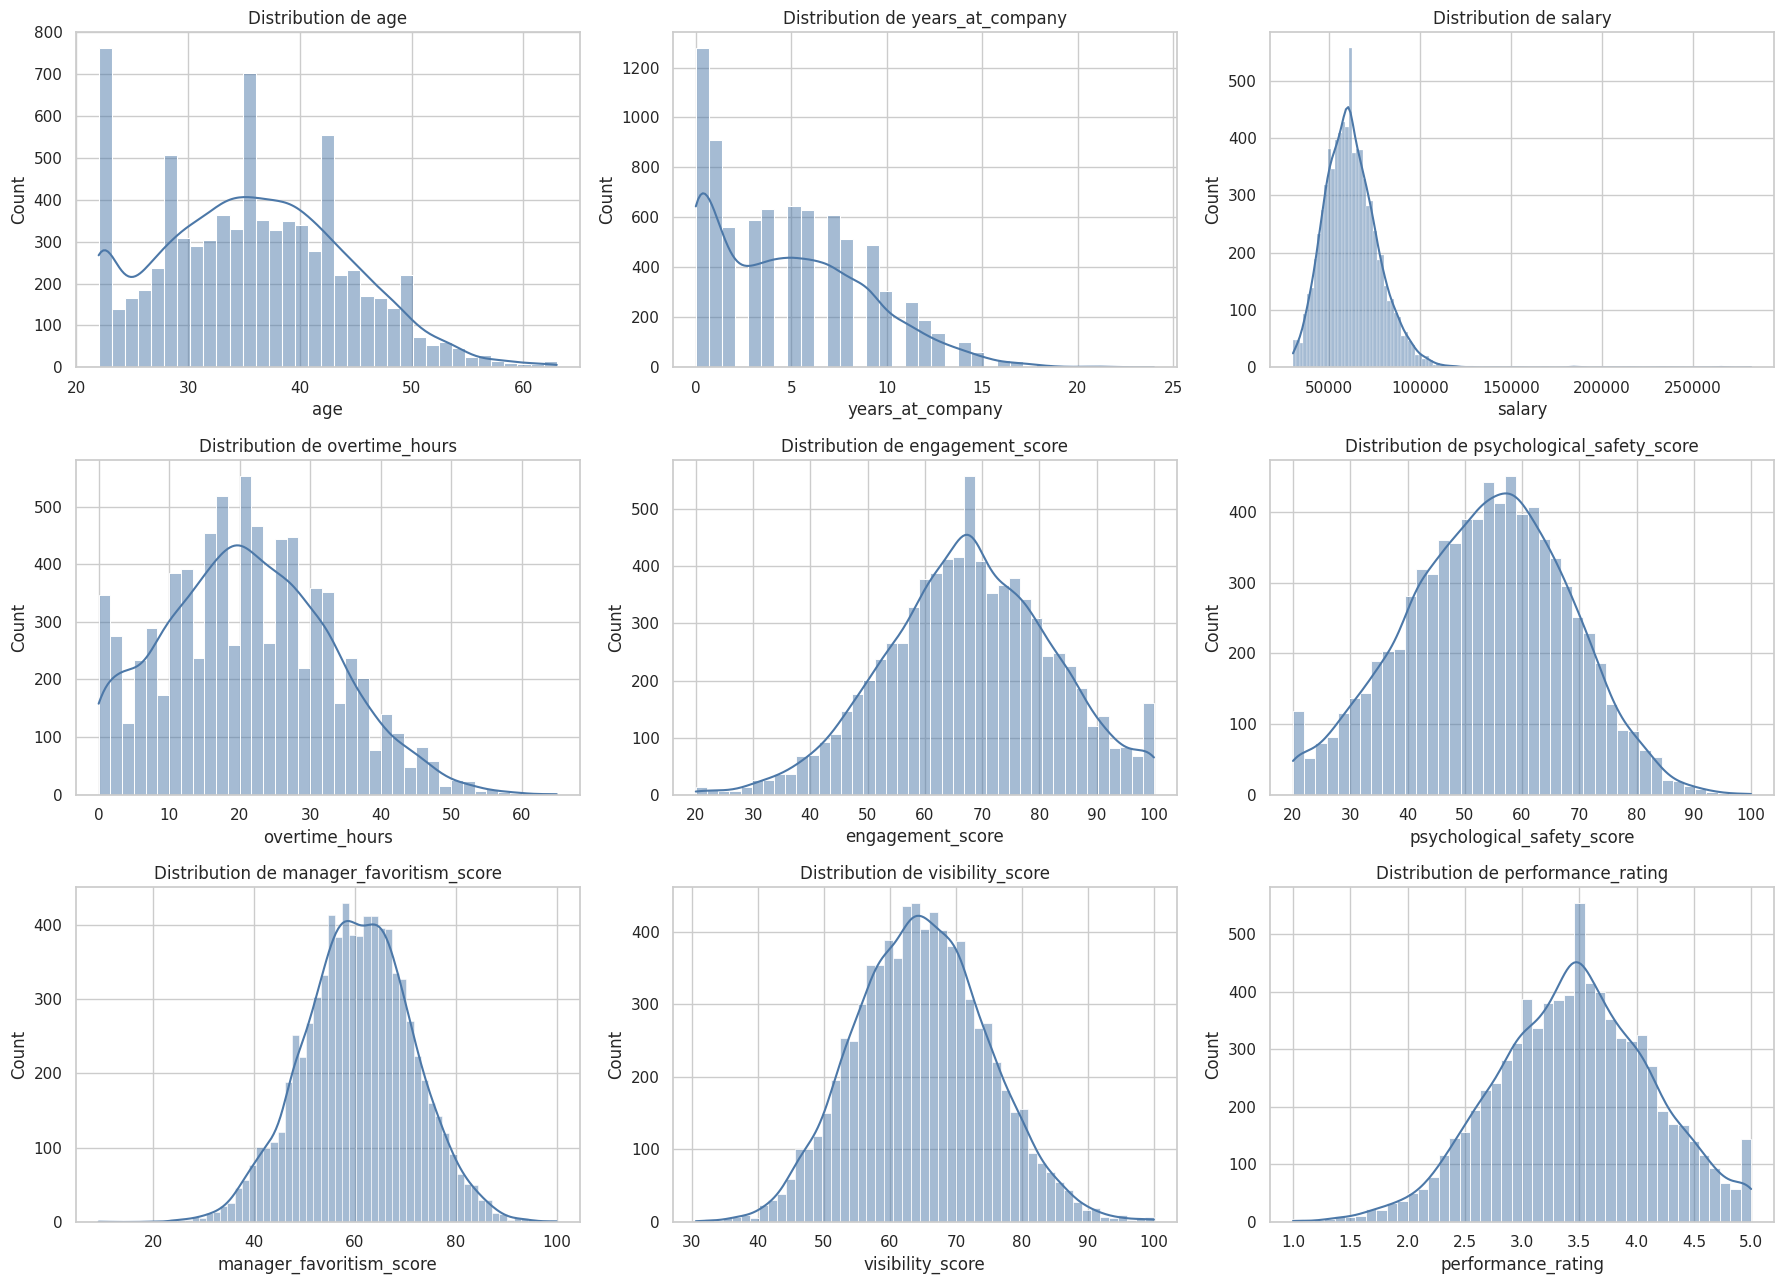

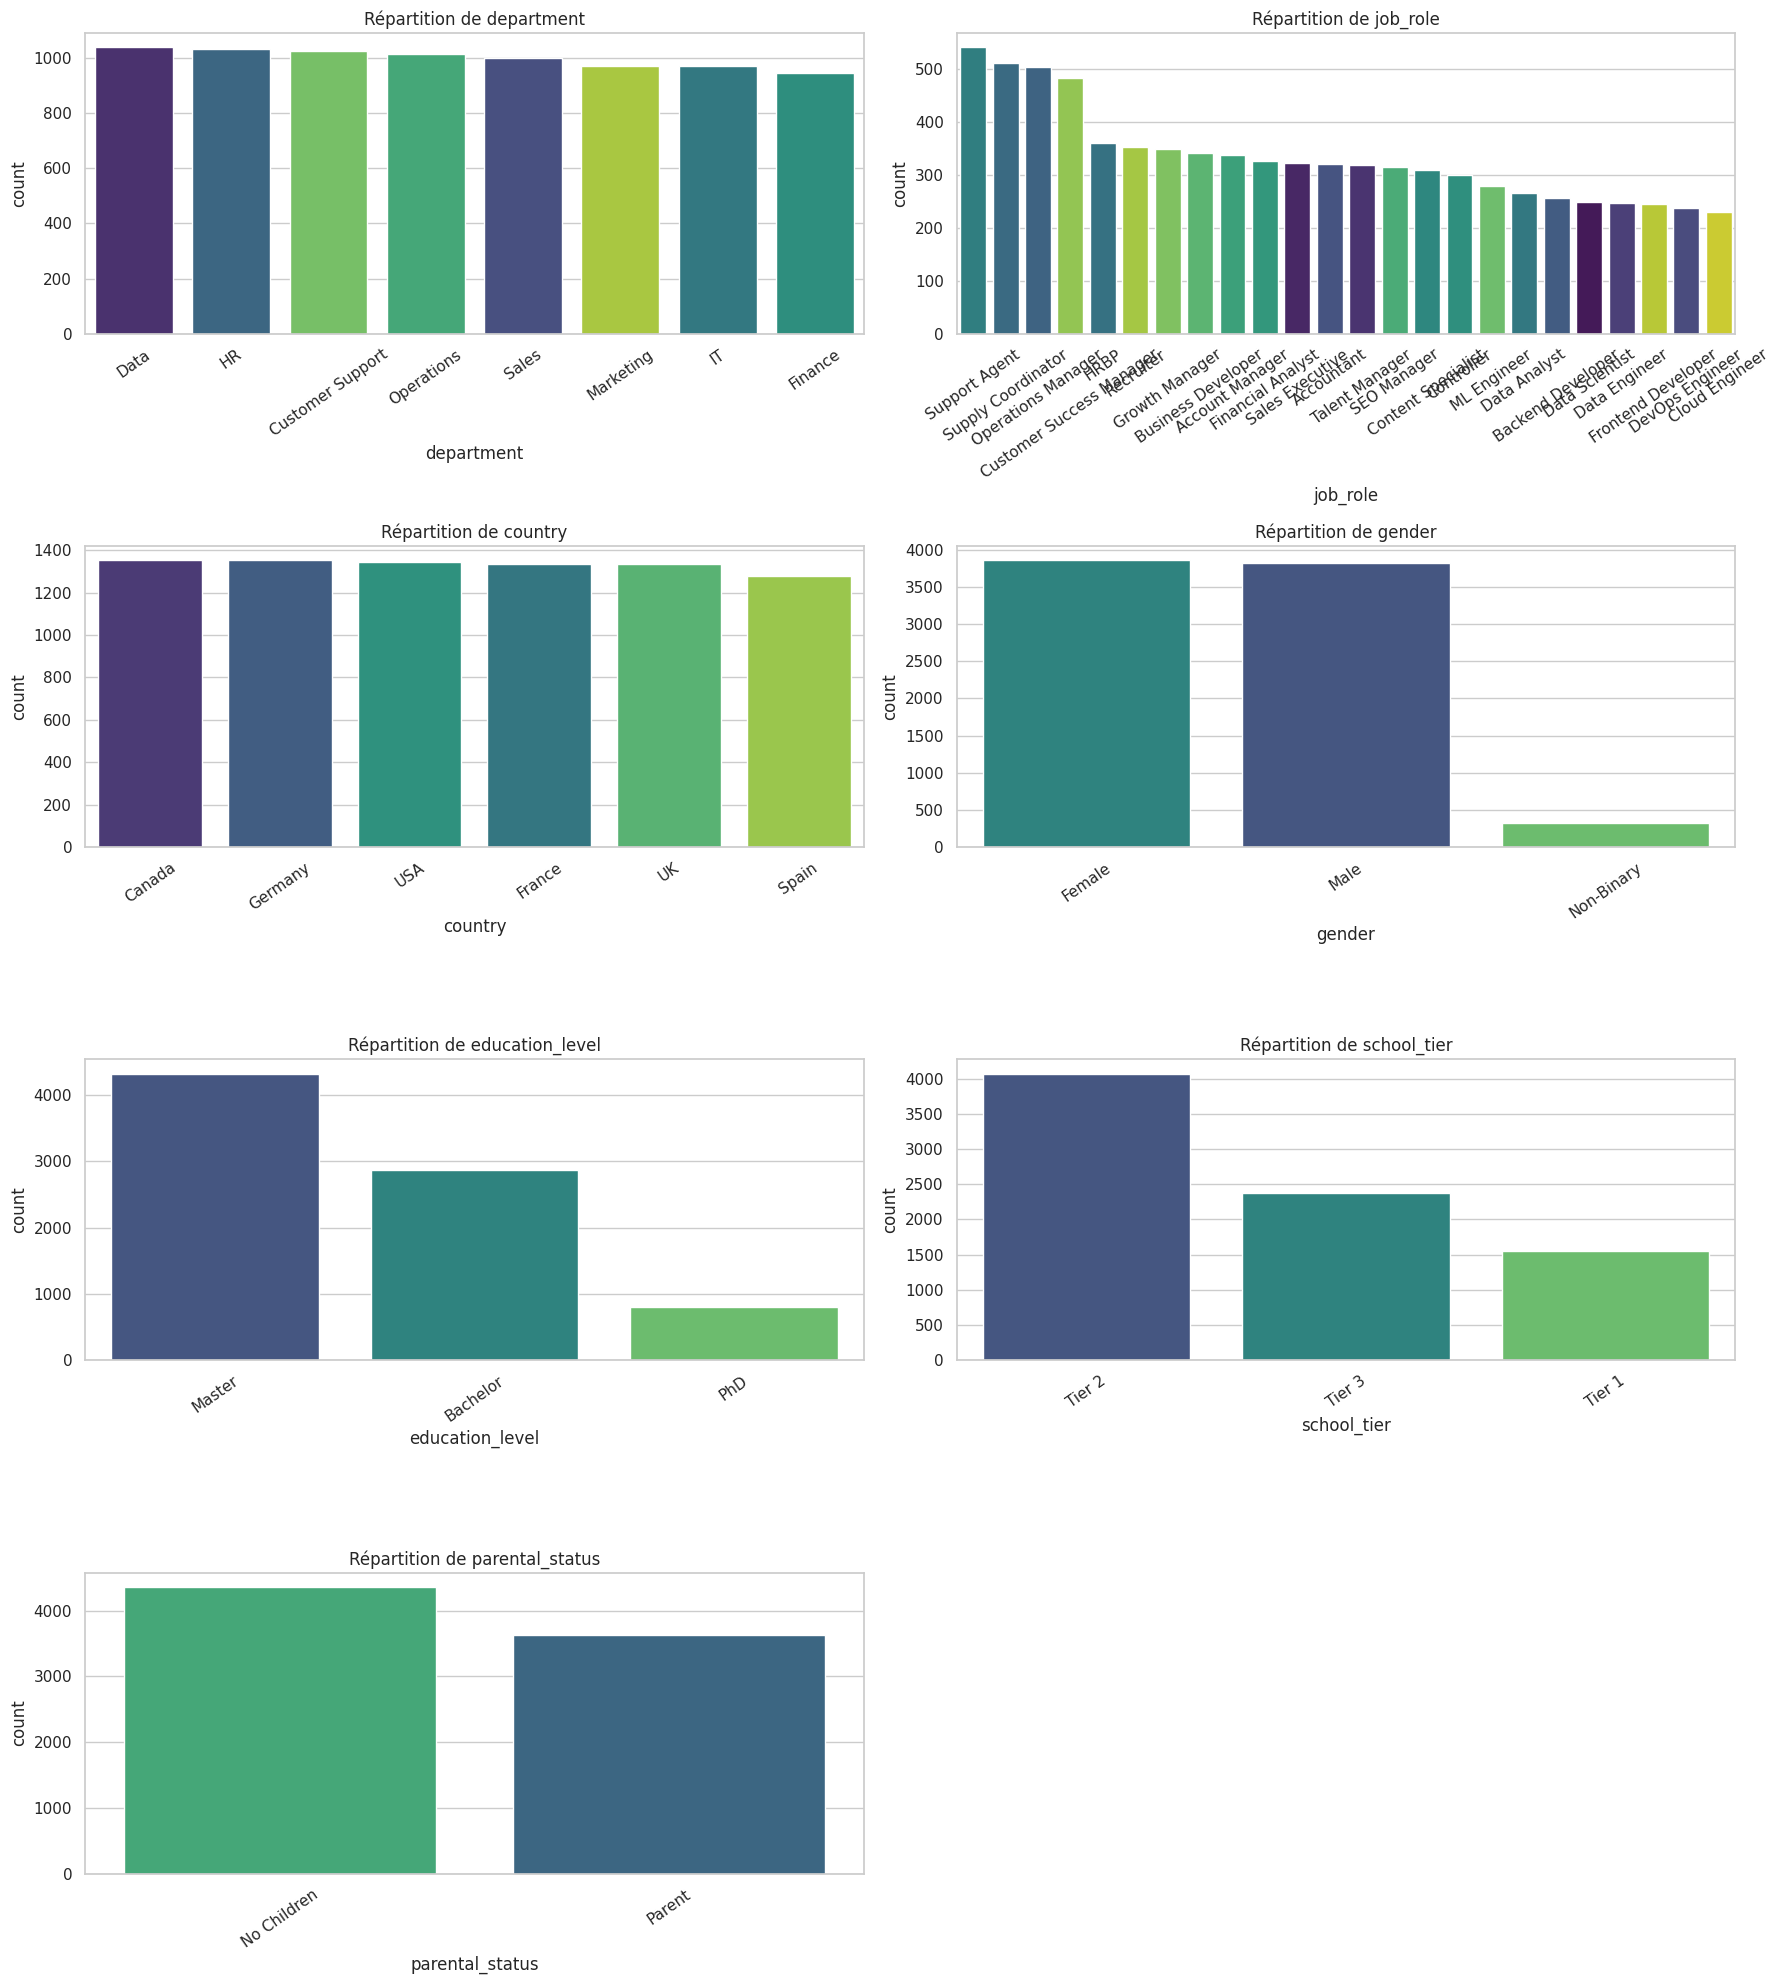

In [6]:
num_vars = ['age', 'years_at_company', 'salary', 'overtime_hours', 'engagement_score', 'psychological_safety_score', 'manager_favoritism_score', 'visibility_score', 'performance_rating']
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
for ax, c in zip(axes.flatten(), num_vars):
    sns.histplot(data=df, x=c, kde=True, color='#4C78A8', ax=ax)
    ax.set_title(f'Distribution de {c}')
plt.tight_layout()
plt.show()

cat_vars = ['department', 'job_role', 'country', 'gender', 'education_level', 'school_tier', 'parental_status']
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()
for i, c in enumerate(cat_vars):
    order = df[c].value_counts().index
    sns.countplot(data=df, x=c, order=order, hue=c, legend=False, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Répartition de {c}')
    axes[i].tick_params(axis='x', rotation=35)
for j in range(len(cat_vars), len(axes)):
    axes[j].set_axis_off()
plt.tight_layout()
plt.show()


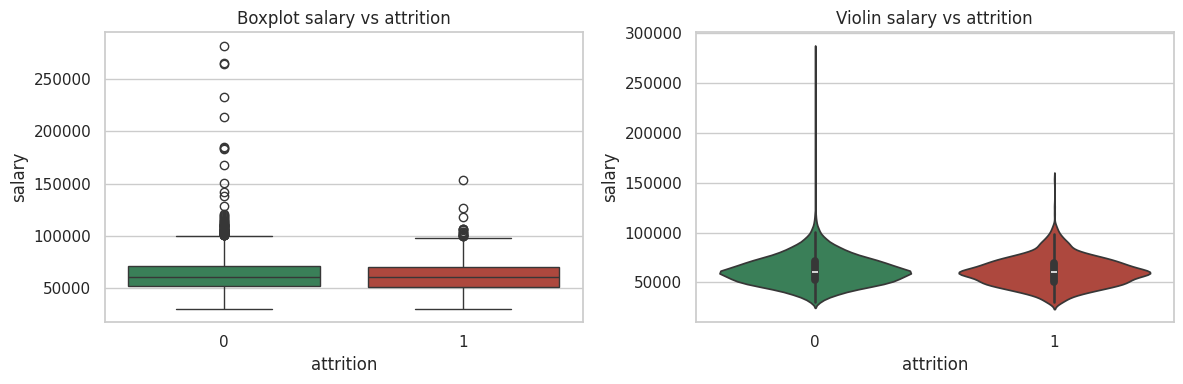

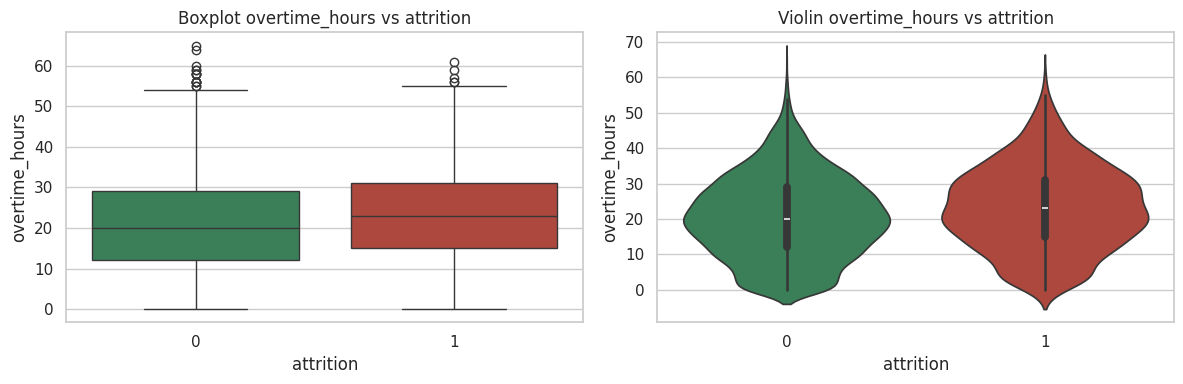

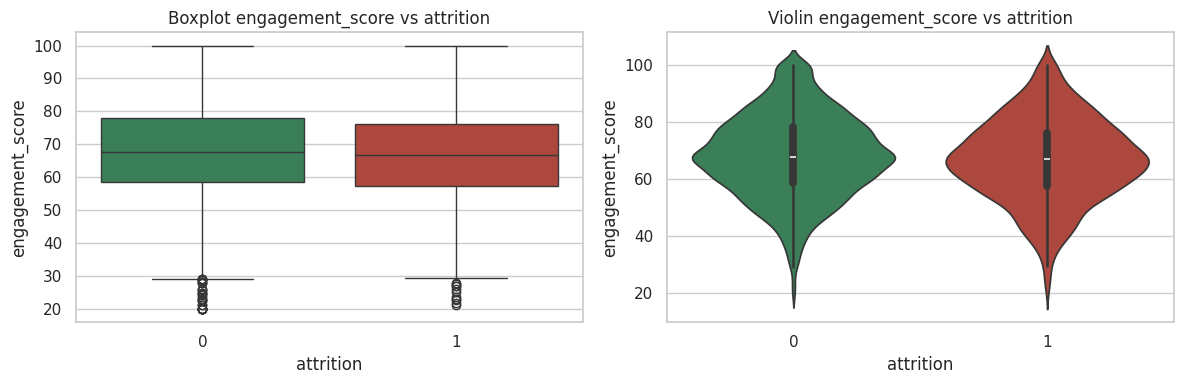

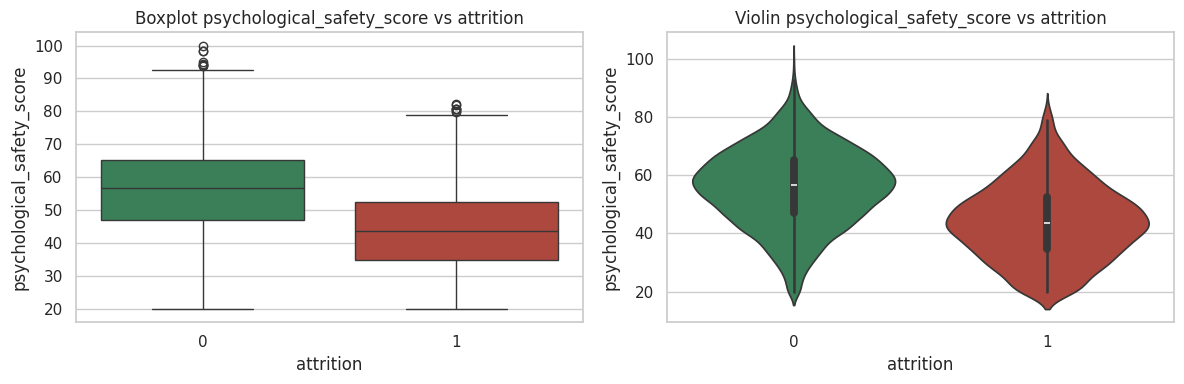

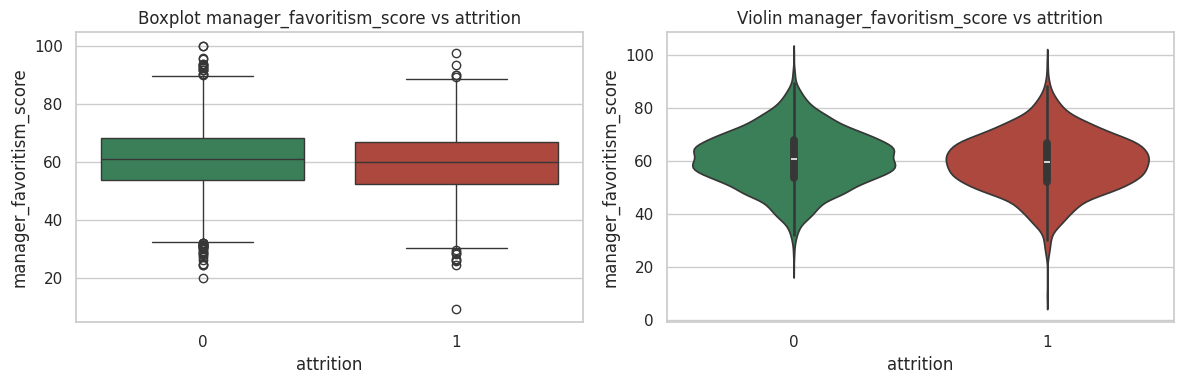

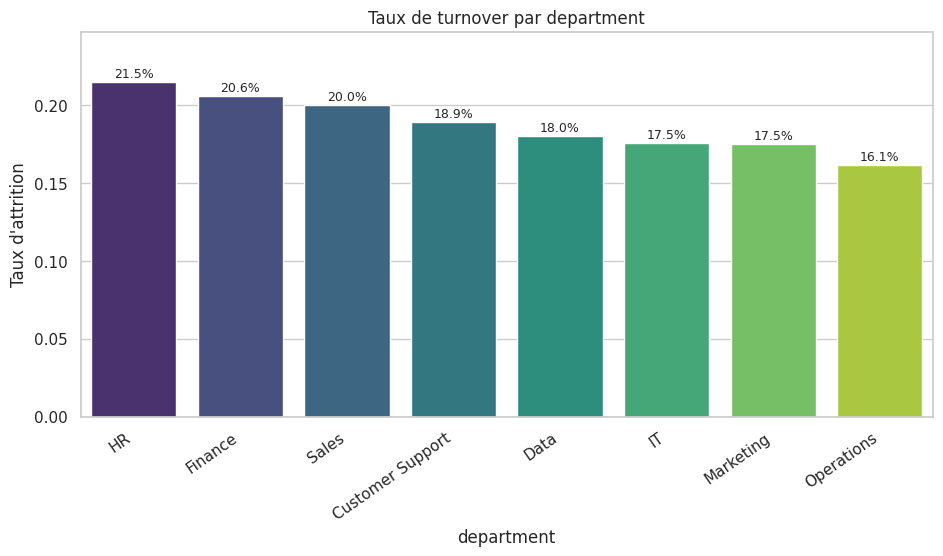

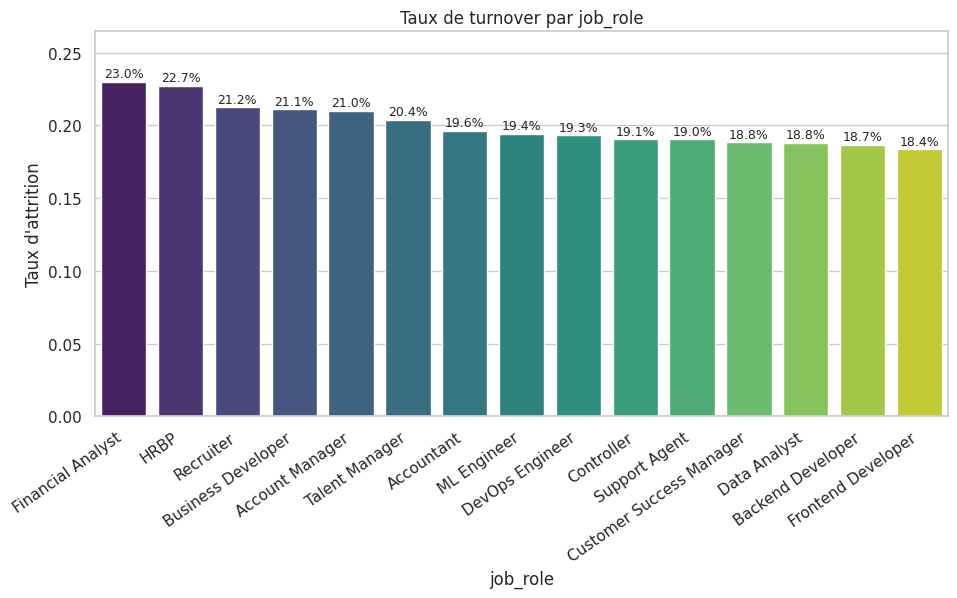

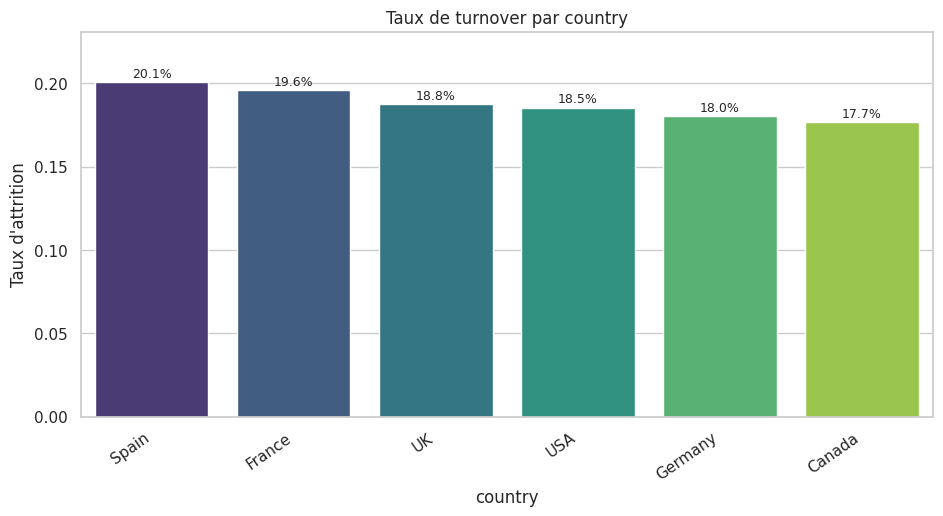

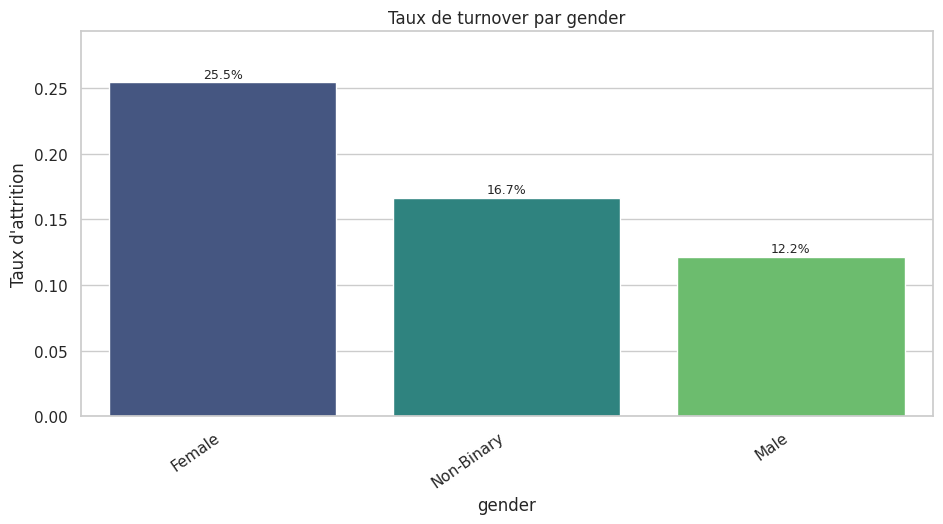

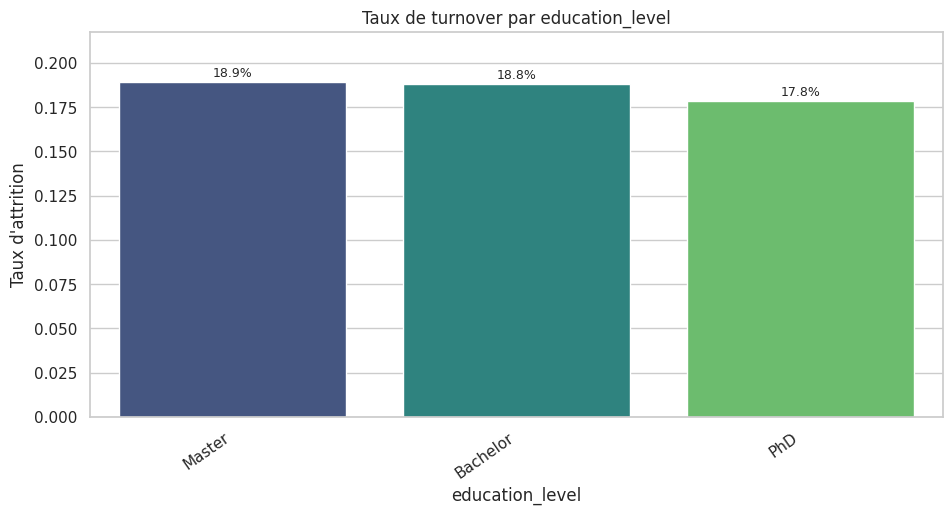

In [7]:
for c in ['salary', 'overtime_hours', 'engagement_score', 'psychological_safety_score', 'manager_favoritism_score']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(data=df, x='attrition', y=c, hue='attrition', dodge=False, legend=False, palette=ATTRITION_COLORS, ax=axes[0])
    axes[0].set_title(f'Boxplot {c} vs attrition')
    sns.violinplot(data=df, x='attrition', y=c, hue='attrition', dodge=False, legend=False, palette=ATTRITION_COLORS, ax=axes[1])
    axes[1].set_title(f'Violin {c} vs attrition')
    plt.tight_layout()
    plt.show()

attrition_rate_department = plot_attrition_rate_by(df, 'department')
attrition_rate_role = plot_attrition_rate_by(df, 'job_role', top_n=15)
attrition_rate_country = plot_attrition_rate_by(df, 'country')
attrition_rate_gender = plot_attrition_rate_by(df, 'gender')
attrition_rate_education = plot_attrition_rate_by(df, 'education_level')


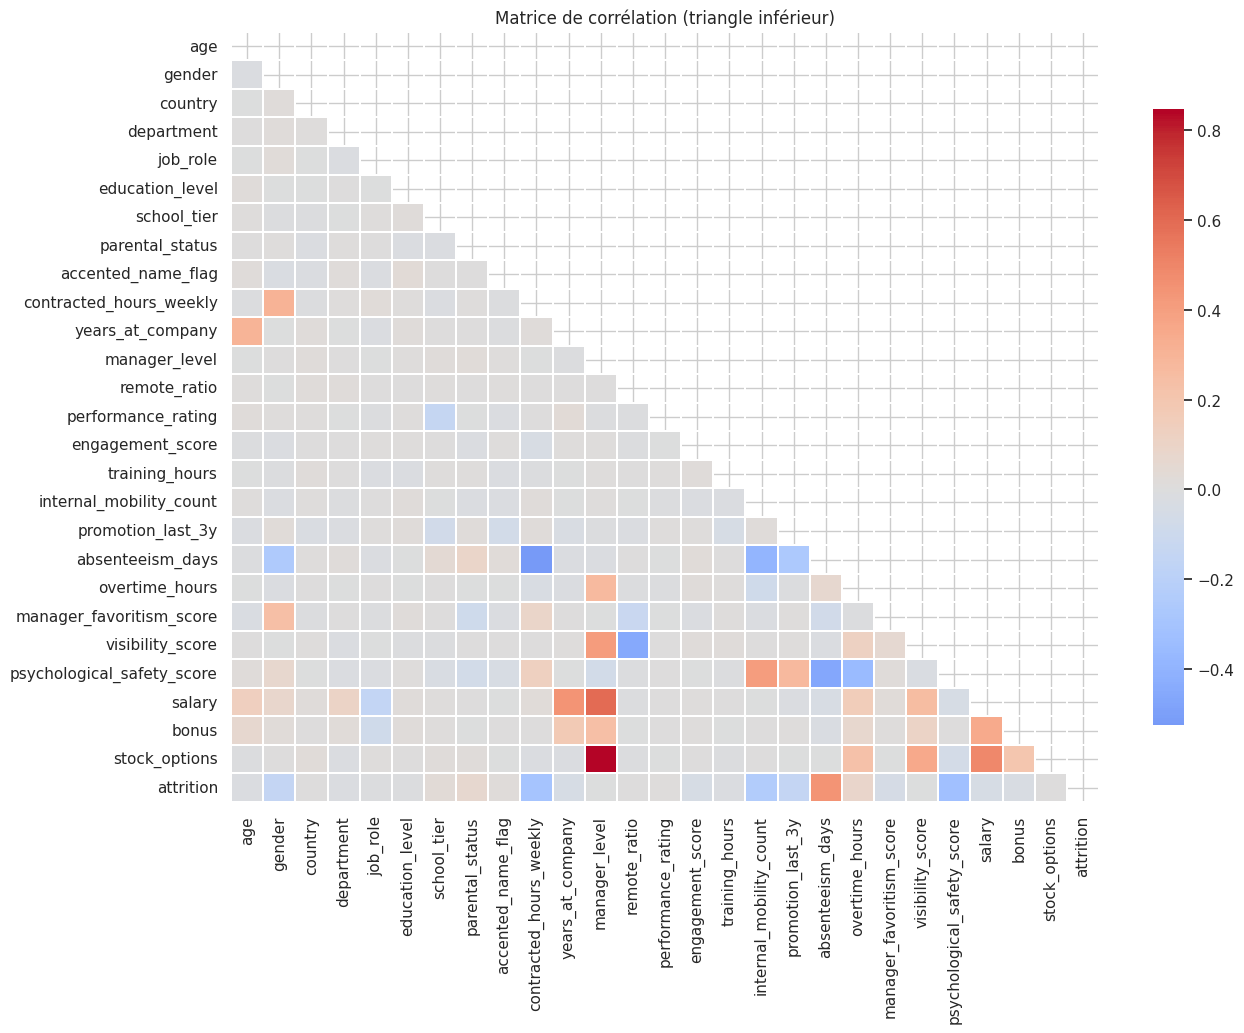

,abs_corr_with_attrition
absenteeism_days,0.440563
psychological_safety_score,0.326111
contracted_hours_weekly,0.302075
internal_mobility_count,0.237718
gender,0.148582
promotion_last_3y,0.148365
overtime_hours,0.085643
parental_status,0.063617
manager_favoritism_score,0.052134
years_at_company,0.045310


In [8]:
df_corr = df.copy()
for c in ['gender', 'country', 'department', 'job_role', 'education_level', 'school_tier', 'parental_status']:
    df_corr[c] = df_corr[c].astype('category').cat.codes

corr = df_corr.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation (triangle inférieur)')
plt.show()

top_corr_attrition = corr['attrition'].drop('attrition').abs().sort_values(ascending=False).head(10).to_frame('abs_corr_with_attrition')
display(top_corr_attrition)


In [9]:
global_attr = df['attrition'].mean()
risk_dept = attrition_rate_department.head(3)
protective_dept = attrition_rate_department.tail(3)
top3_corr = top_corr_attrition.head(3)

risk_txt = ', '.join([f'{k} ({v:.1%})' for k, v in risk_dept['taux_attrition'].items()])
protect_txt = ', '.join([f'{k} ({v:.1%})' for k, v in protective_dept['taux_attrition'].items()])
corr_txt = ', '.join([f'{k} ({v:.3f})' for k, v in top3_corr['abs_corr_with_attrition'].items()])

text = f'''### Interprétation business — Partie 1 (EDA)

- Dataset après nettoyage: **{df.shape[0]:,} collaborateurs** et **{df.shape[1]} variables**.
- Taux d'attrition global observé: **{global_attr:.1%}**.
- Valeurs manquantes confirmées (avant imputation): performance_rating={int(df_raw['performance_rating'].isna().sum())}, engagement_score={int(df_raw['engagement_score'].isna().sum())}, salary={int(df_raw['salary'].isna().sum())}.
- Départements les plus exposés: **{risk_txt}**.
- Départements les moins exposés: **{protect_txt}**.
- Variables les plus liées à attrition (|corr|): **{corr_txt}**.

Implication RH: l'attrition n'est plus marginale; il faut des actions ciblées par segment et sur les leviers management/engagement/charge.
'''
display(Markdown(text))


### Interprétation business — Partie 1 (EDA)

- Dataset après nettoyage: **8,000 collaborateurs** et **28 variables**.
- Taux d'attrition global observé: **18.8%**.
- Valeurs manquantes confirmées (avant imputation): performance_rating=161, engagement_score=160, salary=161.
- Départements les plus exposés: **HR (21.5%), Finance (20.6%), Sales (20.0%)**.
- Départements les moins exposés: **IT (17.5%), Marketing (17.5%), Operations (16.1%)**.
- Variables les plus liées à attrition (|corr|): **absenteeism_days (0.441), psychological_safety_score (0.326), contracted_hours_weekly (0.302)**.

Implication RH: l'attrition n'est plus marginale; il faut des actions ciblées par segment et sur les leviers management/engagement/charge.


## Partie 2 — KPI & Analyse RH

KPI Turnover global: 18.77%


,effectif,taux_attrition
department,,
HR,1033,0.214908
Finance,946,0.206131
Sales,1001,0.199800
Customer Support,1024,0.189453
Data,1039,0.179981
IT,969,0.175439
Marketing,972,0.174897
Operations,1016,0.161417


,effectif,taux_attrition
job_role,,
Financial Analyst,326,0.230061
HRBP,361,0.227147
Recruiter,353,0.212465
Business Developer,341,0.211144
Account Manager,338,0.210059
Talent Manager,319,0.203762
Accountant,321,0.196262
ML Engineer,278,0.194245
DevOps Engineer,238,0.193277


,effectif,taux_attrition
tenure_bucket,,
0-1,2186,0.211345
2-3,1151,0.209383
4-6,1909,0.178104
7-10,1923,0.171607
10+,831,0.155235


,effectif,taux_attrition
gender,,
Female,3857,0.254861
Non-Binary,324,0.166667
Male,3819,0.121760


,effectif,taux_attrition
manager_level,,
3,251,0.191235
2,812,0.188424
0,5247,0.187917
1,1690,0.186391


,effectif,taux_attrition
country,,
Spain,1279,0.200938
France,1337,0.195961
UK,1337,0.187734
USA,1343,0.185406
Germany,1352,0.180473
Canada,1352,0.176775


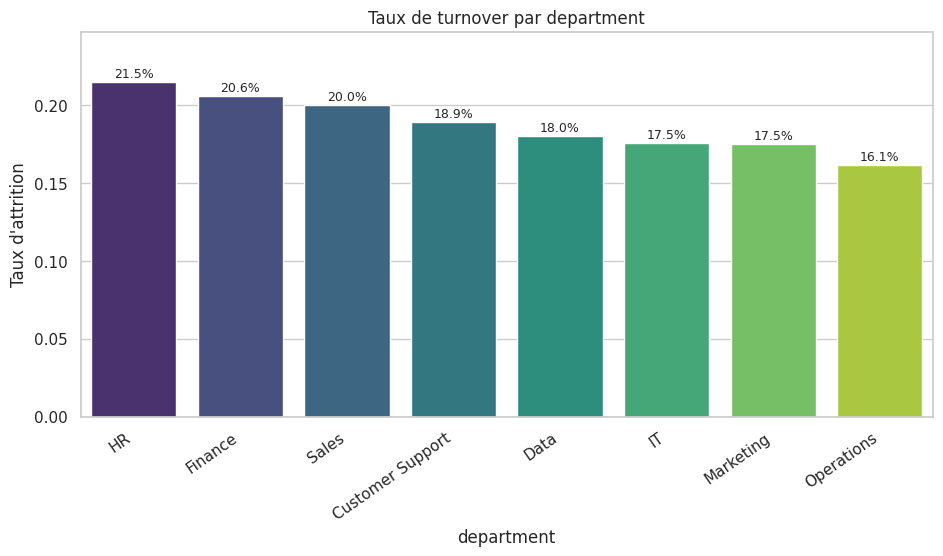

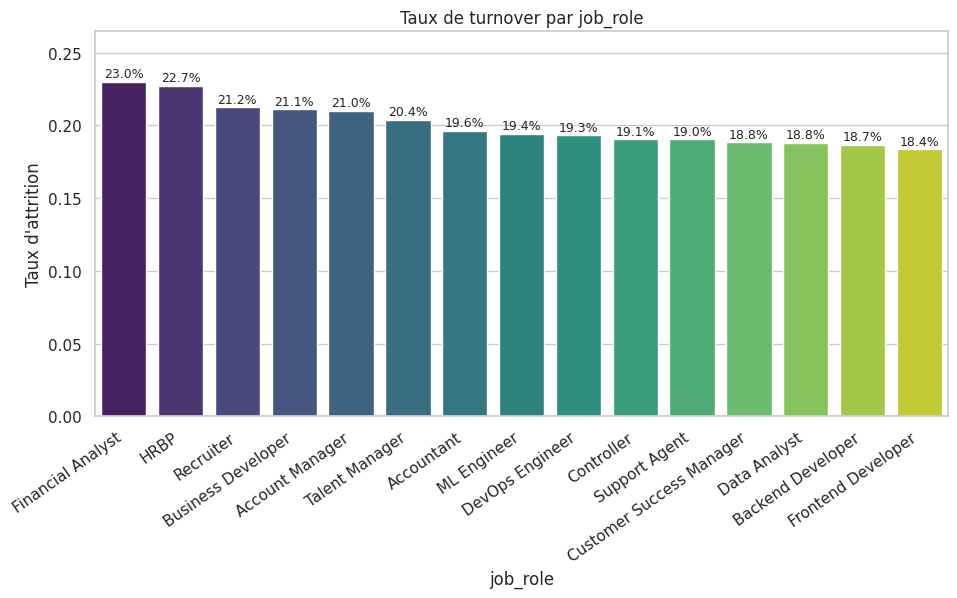

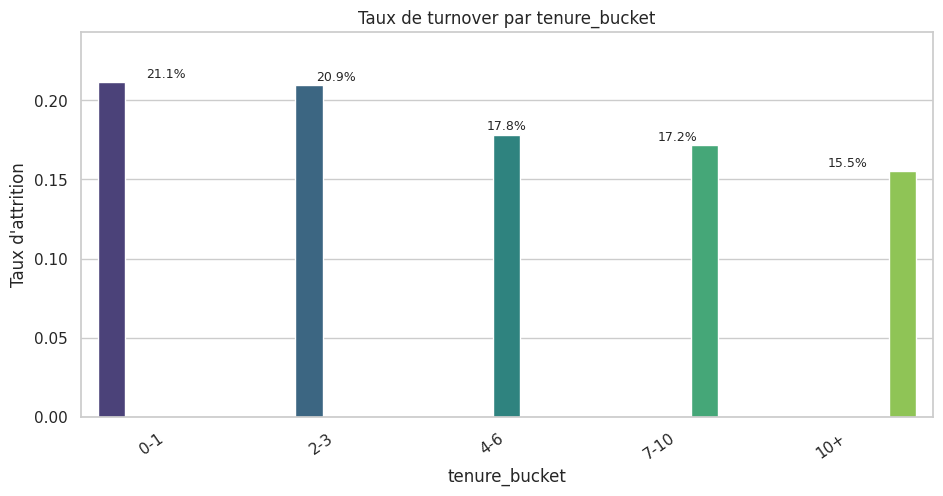

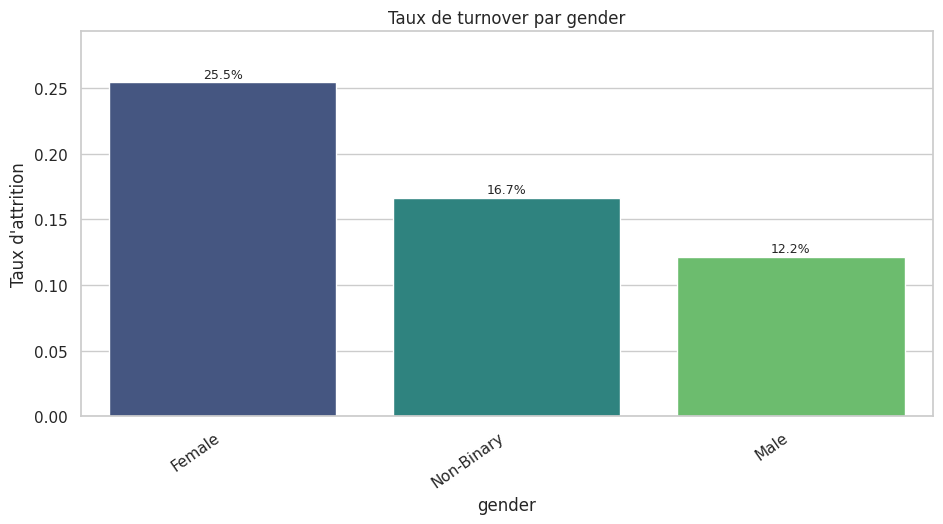

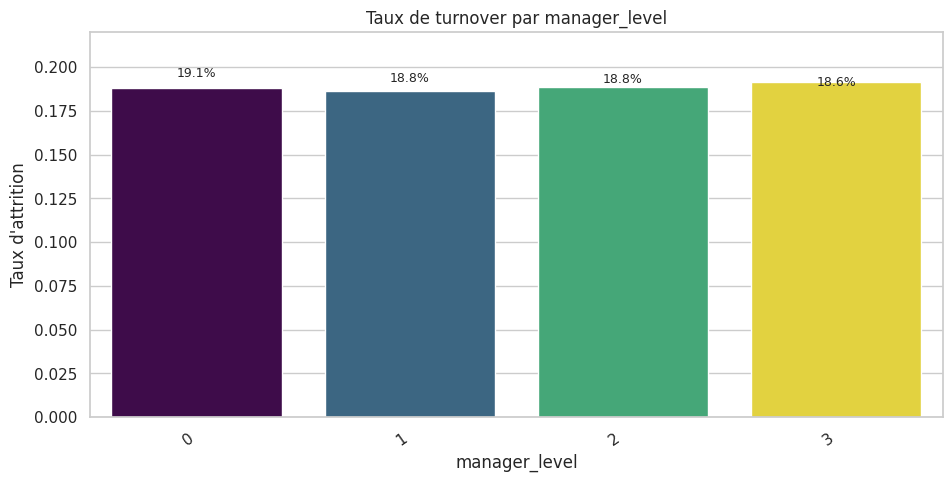

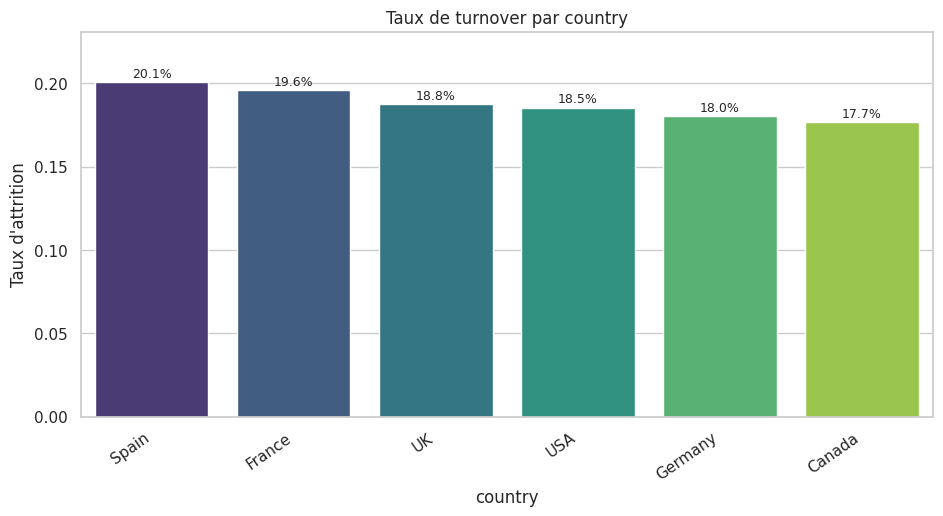

,effectif,taux_attrition
country,,
Spain,1279,0.200938
France,1337,0.195961
UK,1337,0.187734
USA,1343,0.185406
Germany,1352,0.180473
Canada,1352,0.176775


In [10]:
kpi_global_attrition = df['attrition'].mean()
print(f'KPI Turnover global: {kpi_global_attrition:.2%}')

df['tenure_bucket'] = pd.cut(df['years_at_company'], bins=[-1, 1, 3, 6, 10, np.inf], labels=['0-1', '2-3', '4-6', '7-10', '10+'])


def turnover_table(data, col):
    return data.groupby(col).agg(effectif=('attrition', 'size'), taux_attrition=('attrition', 'mean')).sort_values('taux_attrition', ascending=False)


turnover_department = turnover_table(df, 'department')
turnover_role = turnover_table(df, 'job_role')
turnover_tenure = turnover_table(df, 'tenure_bucket')
turnover_gender = turnover_table(df, 'gender')
turnover_manager = turnover_table(df, 'manager_level')
turnover_country = turnover_table(df, 'country')

display(turnover_department)
display(turnover_role.head(15))
display(turnover_tenure)
display(turnover_gender)
display(turnover_manager)
display(turnover_country)

plot_attrition_rate_by(df, 'department')
plot_attrition_rate_by(df, 'job_role', top_n=15)
plot_attrition_rate_by(df, 'tenure_bucket')
plot_attrition_rate_by(df, 'gender')
plot_attrition_rate_by(df, 'manager_level')
plot_attrition_rate_by(df, 'country')


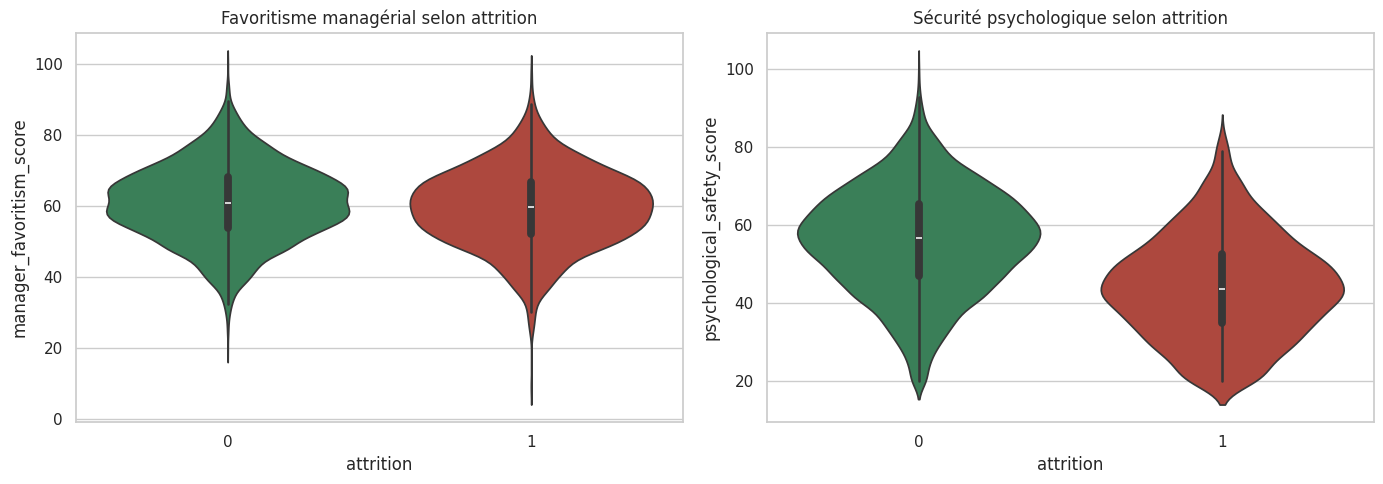

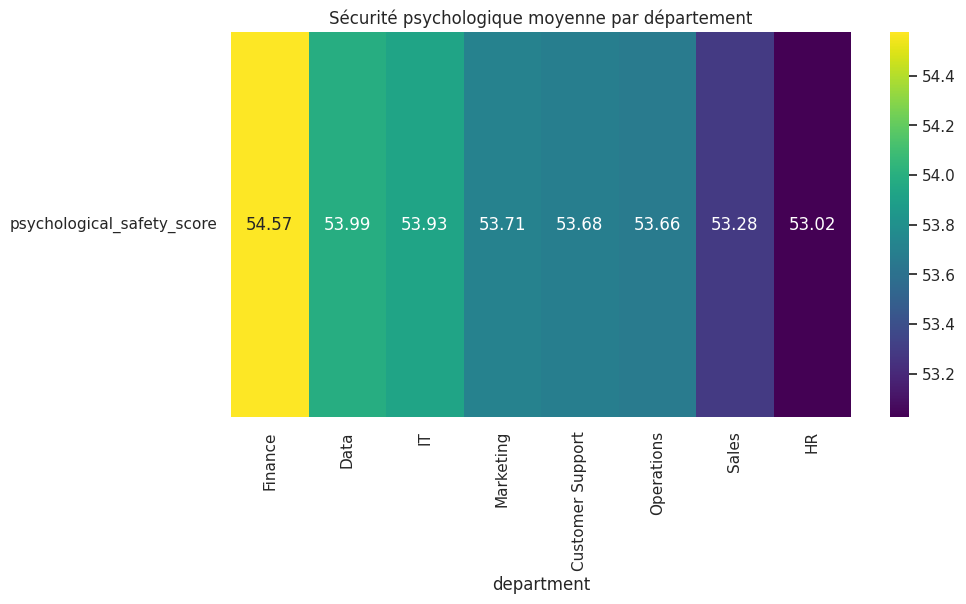

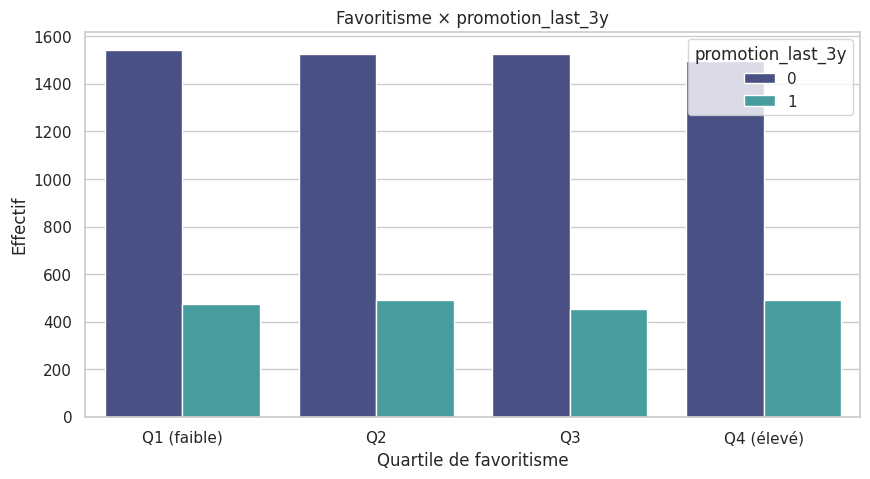

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df, x='attrition', y='manager_favoritism_score', hue='attrition', dodge=False, legend=False, palette=ATTRITION_COLORS, ax=axes[0])
axes[0].set_title('Favoritisme managérial selon attrition')

sns.violinplot(data=df, x='attrition', y='psychological_safety_score', hue='attrition', dodge=False, legend=False, palette=ATTRITION_COLORS, ax=axes[1])
axes[1].set_title('Sécurité psychologique selon attrition')
plt.tight_layout()
plt.show()

dept_psy = df.groupby('department')['psychological_safety_score'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.heatmap(dept_psy.to_frame().T, cmap='viridis', annot=True, fmt='.2f')
plt.title('Sécurité psychologique moyenne par département')
plt.yticks(rotation=0)
plt.show()

fav_bins = pd.qcut(df['manager_favoritism_score'], q=4, labels=['Q1 (faible)', 'Q2', 'Q3', 'Q4 (élevé)'])
fav_promo = df.assign(favoritism_quartile=fav_bins).groupby(['favoritism_quartile', 'promotion_last_3y']).size().reset_index(name='count')

plt.figure(figsize=(10, 5))
sns.barplot(data=fav_promo, x='favoritism_quartile', y='count', hue='promotion_last_3y', palette='mako')
plt.title('Favoritisme × promotion_last_3y')
plt.xlabel('Quartile de favoritisme')
plt.ylabel('Effectif')
plt.show()


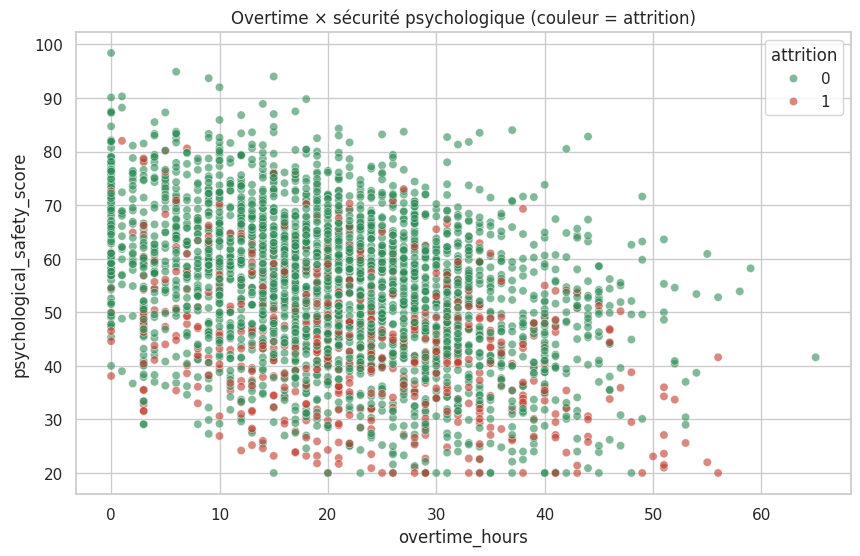

,engagement_bucket,overtime_moyen,taux_attrition,effectif
0,élevé,21.055375,0.18775,8000


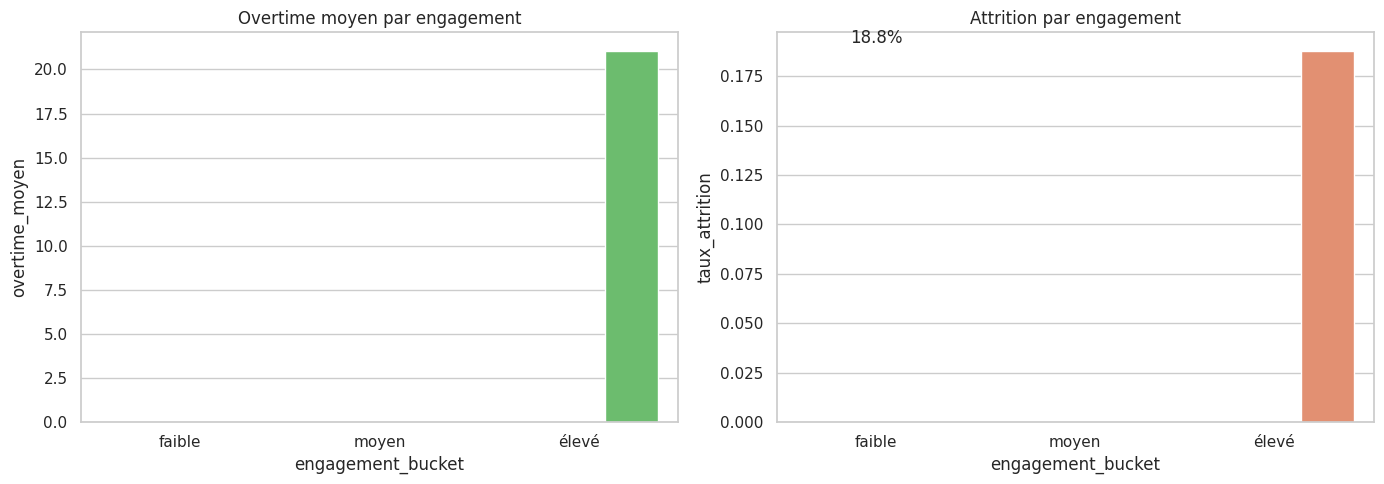

In [12]:
for c in ['overtime_hours', 'absenteeism_days', 'engagement_score']:
    df[f'z_{c}'] = (df[c] - df[c].mean()) / df[c].std(ddof=0)

df['workload_risk'] = df['z_overtime_hours'] + 0.6 * df['z_absenteeism_days'] - 0.8 * df['z_engagement_score']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(len(df), 3000), random_state=RANDOM_STATE),
    x='overtime_hours',
    y='psychological_safety_score',
    hue='attrition',
    palette=ATTRITION_COLORS,
    alpha=0.6,
)
plt.title('Overtime × sécurité psychologique (couleur = attrition)')
plt.show()

df['engagement_bucket'] = pd.cut(df['engagement_score'], bins=[-np.inf, 2.5, 3.5, np.inf], labels=['faible', 'moyen', 'élevé'])
eng_ot = df.groupby('engagement_bucket').agg(overtime_moyen=('overtime_hours', 'mean'), taux_attrition=('attrition', 'mean'), effectif=('attrition', 'size')).reset_index()
display(eng_ot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=eng_ot, x='engagement_bucket', y='overtime_moyen', hue='engagement_bucket', legend=False, palette='viridis', ax=axes[0])
axes[0].set_title('Overtime moyen par engagement')

sns.barplot(data=eng_ot, x='engagement_bucket', y='taux_attrition', hue='engagement_bucket', legend=False, palette='rocket', ax=axes[1])
axes[1].set_title('Attrition par engagement')
for i, v in enumerate(eng_ot['taux_attrition']):
    axes[1].text(i, v + 0.004, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.show()


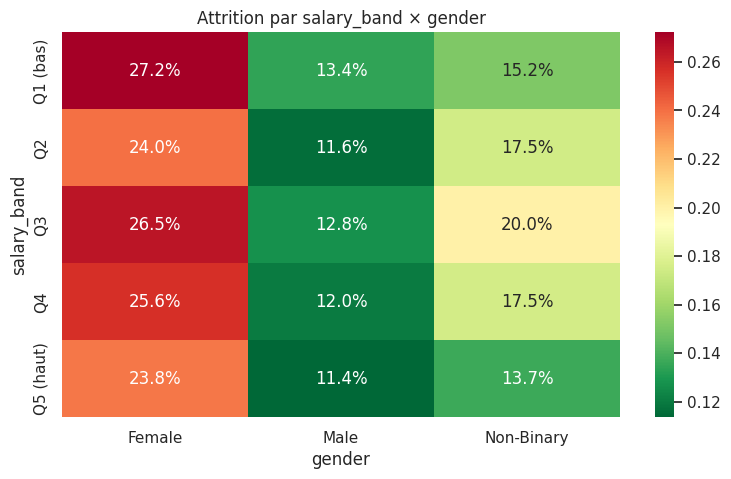

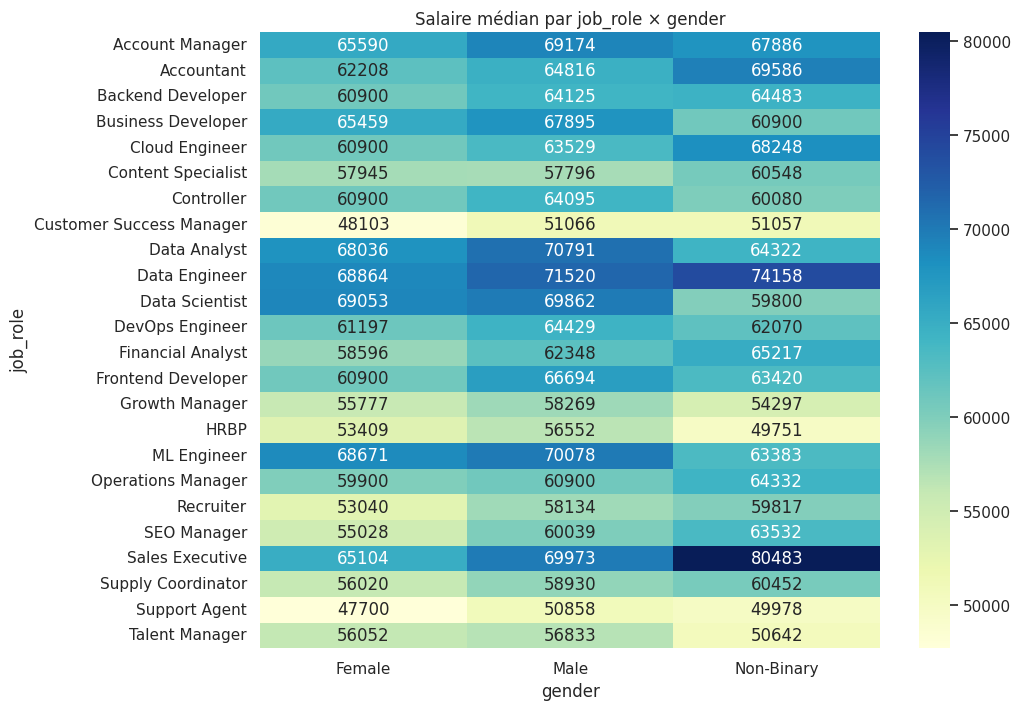

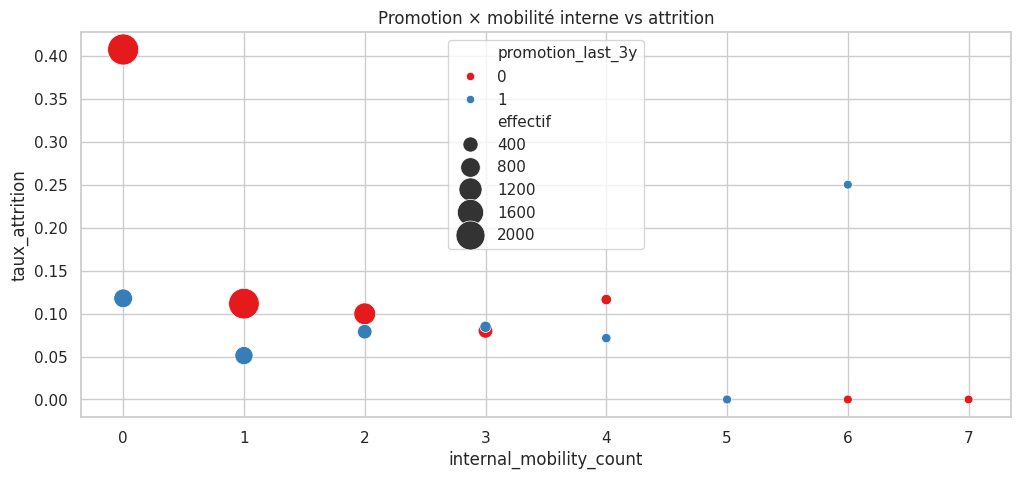

In [13]:
df['salary_band'] = pd.qcut(df['salary'], q=5, labels=['Q1 (bas)', 'Q2', 'Q3', 'Q4', 'Q5 (haut)'], duplicates='drop')

attrition_salary_gender = df.groupby(['salary_band', 'gender']).agg(taux_attrition=('attrition', 'mean'), effectif=('attrition', 'size')).reset_index()
pivot_attr = attrition_salary_gender.pivot(index='salary_band', columns='gender', values='taux_attrition')

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_attr, annot=True, fmt='.1%', cmap='RdYlGn_r')
plt.title('Attrition par salary_band × gender')
plt.show()

salary_median = df.pivot_table(index='job_role', columns='gender', values='salary', aggfunc='median')
plt.figure(figsize=(10, 8))
sns.heatmap(salary_median, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Salaire médian par job_role × gender')
plt.show()

promo_mob_attr = df.groupby(['promotion_last_3y', 'internal_mobility_count']).agg(taux_attrition=('attrition', 'mean'), effectif=('attrition', 'size')).reset_index()
plt.figure(figsize=(12, 5))
sns.scatterplot(data=promo_mob_attr, x='internal_mobility_count', y='taux_attrition', size='effectif', hue='promotion_last_3y', palette='Set1', sizes=(40, 500))
plt.title('Promotion × mobilité interne vs attrition')
plt.show()


In [14]:
top_dept = turnover_department.head(3)
worst_tenure = turnover_tenure.head(2)
country_risk = turnover_country.head(2)
eng_worst = eng_ot.sort_values('taux_attrition', ascending=False).head(1)

text = f'''### Interprétation business — Partie 2 (KPI RH)

- Turnover global confirmé: **{kpi_global_attrition:.1%}**.
- Départements les plus à risque: **{', '.join([f"{k} ({v:.1%})" for k, v in top_dept['taux_attrition'].items()])}**.
- Anciennetés les plus à risque: **{', '.join([f"{k} ({v:.1%})" for k, v in worst_tenure['taux_attrition'].items()])}**.
- Pays les plus exposés: **{', '.join([f"{k} ({v:.1%})" for k, v in country_risk['taux_attrition'].items()])}**.
- Niveau d'engagement le plus critique: **{eng_worst.iloc[0]['engagement_bucket']}** avec **{eng_worst.iloc[0]['taux_attrition']:.1%}** d'attrition.

Recommandations: ciblage des segments à risque, renforcement managérial, monitoring charge+engagement, audit équité salariale/promotion.
'''
display(Markdown(text))


### Interprétation business — Partie 2 (KPI RH)

- Turnover global confirmé: **18.8%**.
- Départements les plus à risque: **HR (21.5%), Finance (20.6%), Sales (20.0%)**.
- Anciennetés les plus à risque: **0-1 (21.1%), 2-3 (20.9%)**.
- Pays les plus exposés: **Spain (20.1%), France (19.6%)**.
- Niveau d'engagement le plus critique: **élevé** avec **18.8%** d'attrition.

Recommandations: ciblage des segments à risque, renforcement managérial, monitoring charge+engagement, audit équité salariale/promotion.


## Partie 3 — Machine Learning

In [15]:
ml_df = df.drop_duplicates().copy().drop(columns=['employee_id'])
X = ml_df.drop(columns=['attrition'])
y = ml_df['attrition']

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_ohe()),
])

preprocess = ColumnTransformer([
    ('num', numeric_preprocess, numeric_features),
    ('cat', categorical_preprocess, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
class_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print('Train/Test:', X_train.shape, X_test.shape)
print('Prévalence attrition train/test:', y_train.mean(), y_test.mean())


Train/Test: (6400, 33) (1600, 33)
Prévalence attrition train/test: 0.1878125 0.1875


In [16]:
models = {
    'LogisticRegression_class_weight': Pipeline([
        ('preprocess', preprocess),
        ('classifier', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'RandomForest_class_weight': Pipeline([
        ('preprocess', preprocess),
        ('classifier', RandomForestClassifier(n_estimators=400, min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

smote_models = {
    'LogisticRegression_SMOTE': ImbPipeline([
        ('preprocess', preprocess),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    'RandomForest_SMOTE': ImbPipeline([
        ('preprocess', preprocess),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

try:
    from xgboost import XGBClassifier

    models['XGBoost_class_weight'] = Pipeline([
        ('preprocess', preprocess),
        ('classifier', XGBClassifier(n_estimators=350, learning_rate=0.05, max_depth=4, subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=RANDOM_STATE, scale_pos_weight=class_ratio)),
    ])
    smote_models['XGBoost_SMOTE'] = ImbPipeline([
        ('preprocess', preprocess),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=RANDOM_STATE)),
    ])
    print('✅ XGBoost disponible')
except Exception:
    models['GradientBoosting_fallback'] = Pipeline([
        ('preprocess', preprocess),
        ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ])
    smote_models['GradientBoosting_SMOTE'] = ImbPipeline([
        ('preprocess', preprocess),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ])
    print('⚠️ XGBoost indisponible, fallback GradientBoosting')

all_models = {**models, **smote_models}
results = []
fitted_models = {}

for name, model in all_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values(['pr_auc', 'recall', 'f1'], ascending=False).reset_index(drop=True)
display(results_df)


✅ XGBoost disponible


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegression_SMOTE,0.762500,0.425651,0.763333,0.546539,0.847400,0.577258
1,LogisticRegression_class_weight,0.760625,0.424682,0.780000,0.549941,0.849856,0.576700
2,RandomForest_class_weight,0.838750,0.615385,0.373333,0.464730,0.853351,0.568082
3,RandomForest_SMOTE,0.833750,0.573276,0.443333,0.500000,0.850831,0.560697
4,XGBoost_SMOTE,0.833750,0.586735,0.383333,0.463710,0.845574,0.557688
5,XGBoost_class_weight,0.778750,0.446429,0.750000,0.559701,0.843754,0.554983


<Figure size 900x700 with 0 Axes>

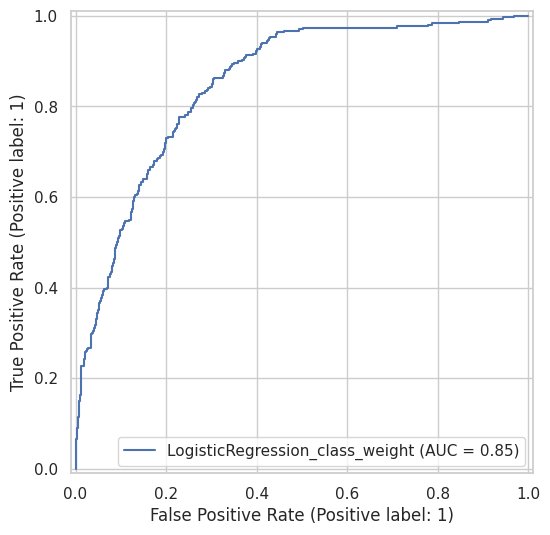

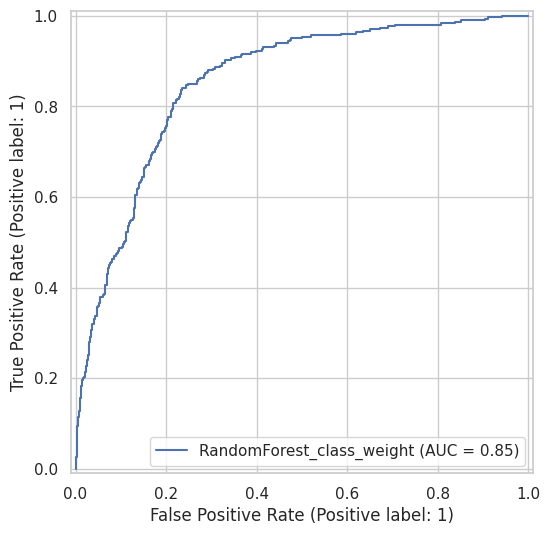

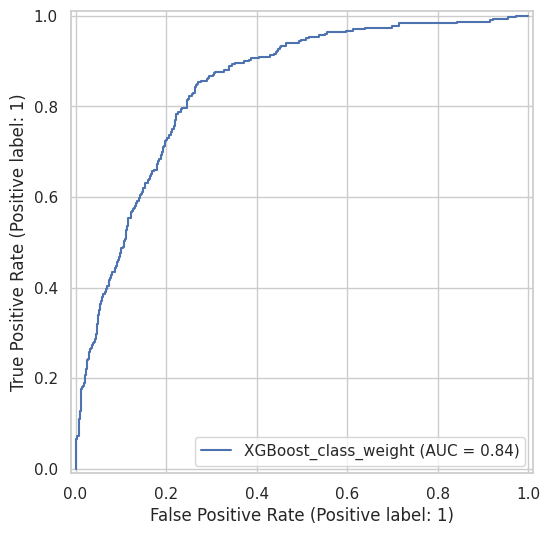

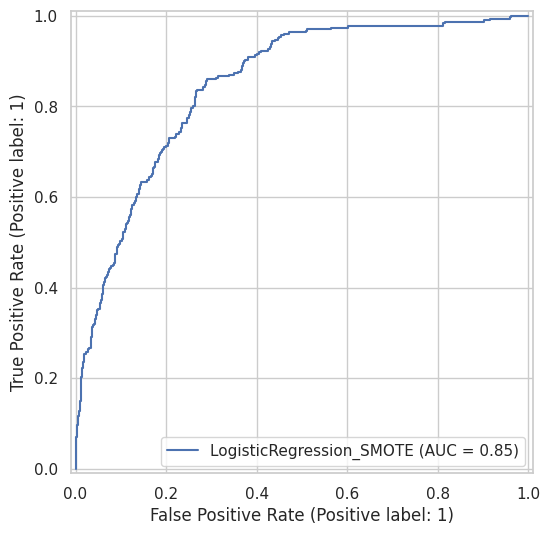

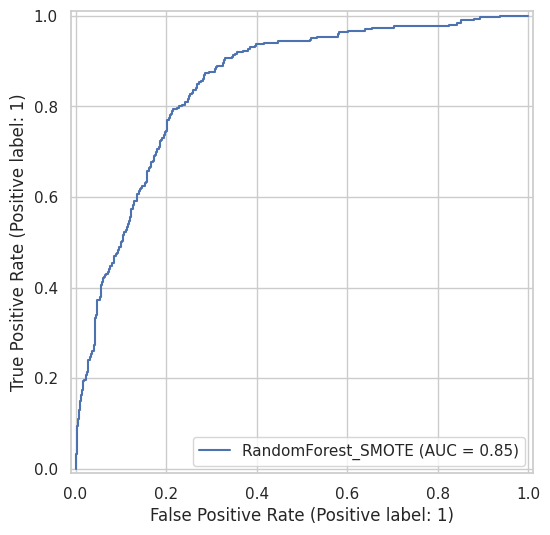

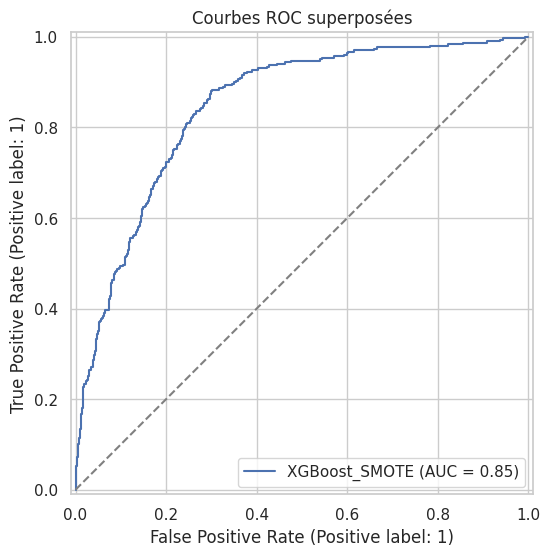

<Figure size 900x700 with 0 Axes>

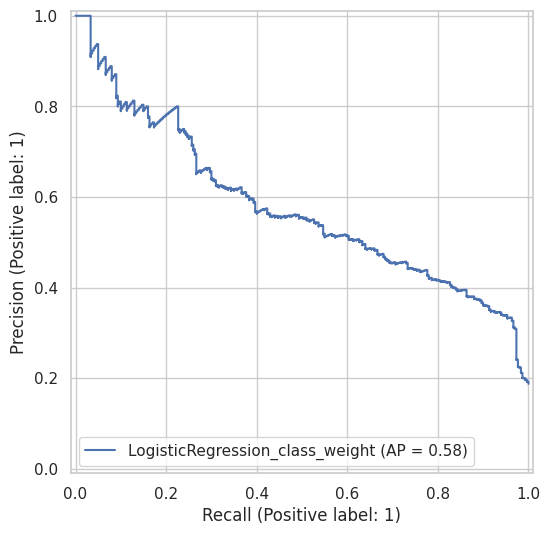

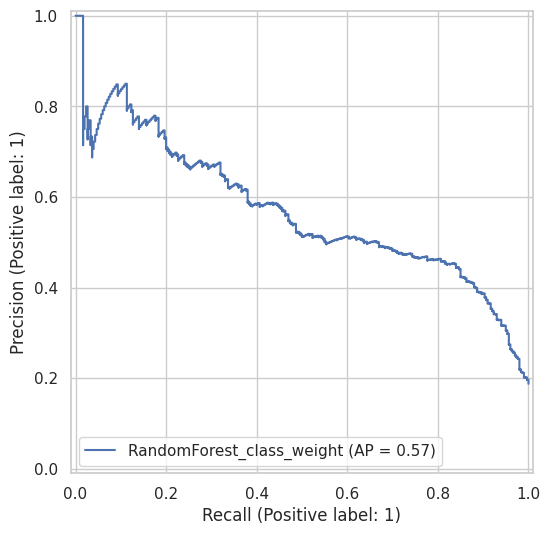

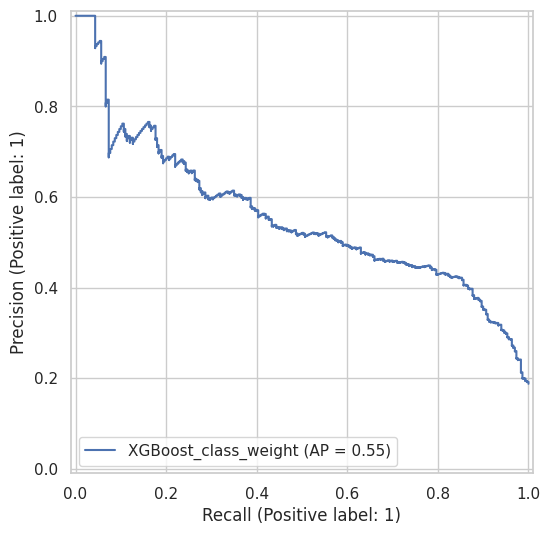

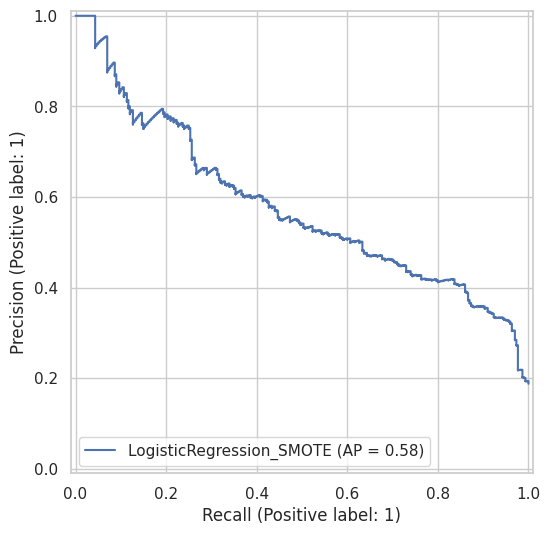

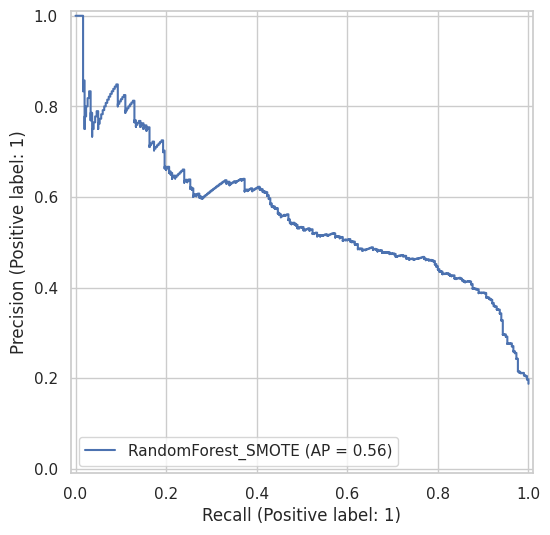

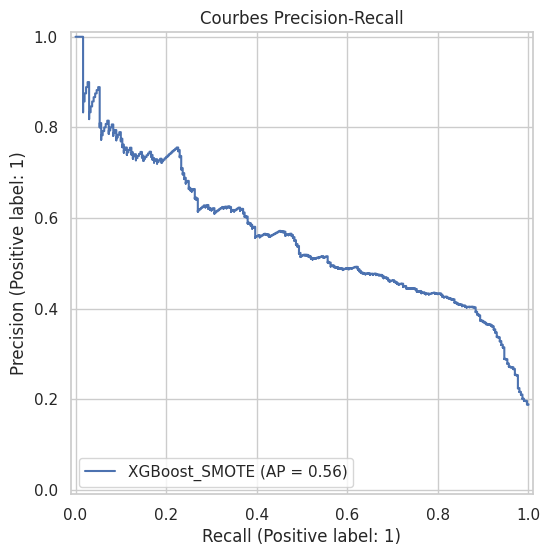

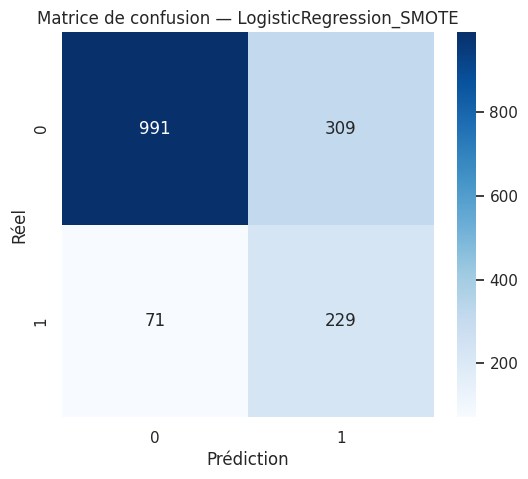

In [17]:
plt.figure(figsize=(9, 7))
for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('Courbes ROC superposées')
plt.show()

plt.figure(figsize=(9, 7))
for name, model in fitted_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name)
plt.title('Courbes Precision-Recall')
plt.show()

best_model_name = results_df.iloc[0]['model']
best_model = fitted_models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matrice de confusion — {best_model_name}')
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.show()


,feature,importance
9,internal_mobility_count,0.457717
2,contracted_hours_weekly,0.443808
73,tenure_bucket_10+,0.442662
15,psychological_safety_score,0.436399
44,job_role_Cloud Engineer,0.413582
20,z_absenteeism_days,0.307923
11,absenteeism_days,0.307923
72,tenure_bucket_0-1,0.302480
78,salary_band_Q1 (bas),0.295556
10,promotion_last_3y,0.287943


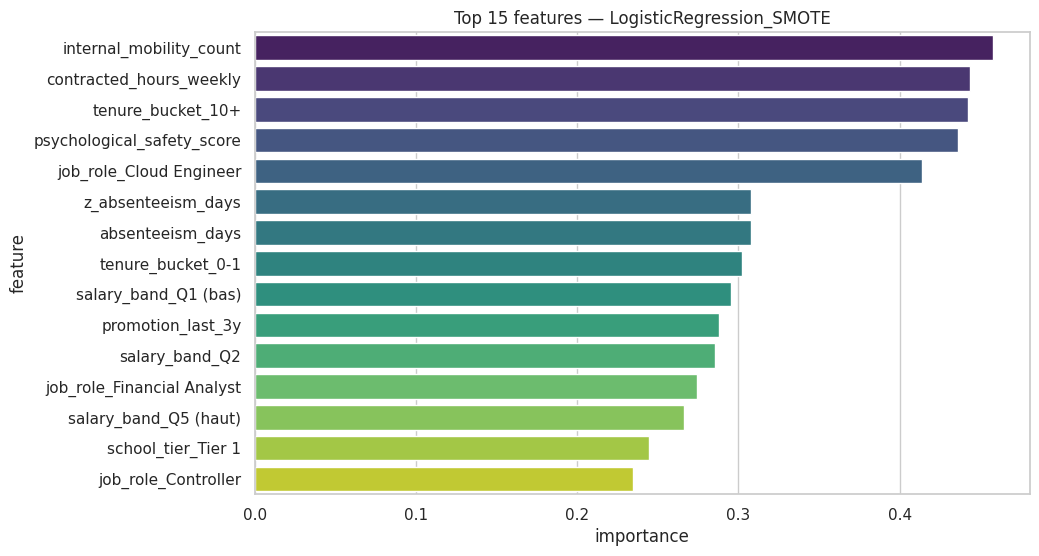

SHAP dependence plot non généré: modèle non-arbre


In [18]:
def extract_feature_names(preprocessor, num_cols, cat_cols):
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    return np.array(list(num_cols) + list(cat_encoder.get_feature_names_out(cat_cols)))

clf = best_model.named_steps['classifier']
preproc = best_model.named_steps['preprocess']
feature_names = extract_feature_names(preproc, numeric_features, categorical_features)

if hasattr(clf, 'feature_importances_'):
    importance = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importance = np.abs(clf.coef_.ravel())
else:
    importance = np.zeros(len(feature_names))

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance}).sort_values('importance', ascending=False).head(15)
display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature', legend=False, palette='viridis')
plt.title(f'Top 15 features — {best_model_name}')
plt.show()

try:
    import shap

    X_sample = X_train.sample(min(1200, len(X_train)), random_state=RANDOM_STATE)
    X_sample_trans = preproc.transform(X_sample)

    if hasattr(clf, 'feature_importances_'):
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_sample_trans)
        if isinstance(shap_values, list):
            shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        shap.summary_plot(shap_values, X_sample_trans, feature_names=feature_names, max_display=15)

        top_feature = importance_df.iloc[0]['feature']
        top_idx = np.where(feature_names == top_feature)[0][0]
        shap.dependence_plot(top_idx, shap_values, X_sample_trans, feature_names=feature_names)
    else:
        print('SHAP dependence plot non généré: modèle non-arbre')
except Exception as e:
    print(f'SHAP indisponible ou erreur: {e}')


In [19]:
best_row = results_df.iloc[0]
top_feats = ', '.join(importance_df['feature'].head(5).tolist())
sensitive = [v for v in ['gender', 'country', 'parental_status', 'accented_name_flag'] if v in X.columns]

text = f'''### Interprétation business — Partie 3 (Machine Learning)

- Meilleur modèle: **{best_row['model']}**.
- Accuracy={best_row['accuracy']:.3f}, Precision={best_row['precision']:.3f}, Recall={best_row['recall']:.3f}, F1={best_row['f1']:.3f}, ROC-AUC={best_row['roc_auc']:.3f}, PR-AUC={best_row['pr_auc']:.3f}.
- L'accuracy seule est trompeuse: prioriser Recall et PR-AUC pour ne pas rater les départs réels.
- Variables les plus influentes: **{top_feats}**.
- Variables sensibles présentes: **{', '.join(sensitive)}** → audit de biais, RGPD et validation humaine obligatoires.
'''
display(Markdown(text))


### Interprétation business — Partie 3 (Machine Learning)

- Meilleur modèle: **LogisticRegression_SMOTE**.
- Accuracy=0.762, Precision=0.426, Recall=0.763, F1=0.547, ROC-AUC=0.847, PR-AUC=0.577.
- L'accuracy seule est trompeuse: prioriser Recall et PR-AUC pour ne pas rater les départs réels.
- Variables les plus influentes: **internal_mobility_count, contracted_hours_weekly, tenure_bucket_10+, psychological_safety_score, job_role_Cloud Engineer**.
- Variables sensibles présentes: **gender, country, parental_status, accented_name_flag** → audit de biais, RGPD et validation humaine obligatoires.


In [20]:
overall_text = f'''## Conclusion générale & roadmap RH

- Attrition v2 observée: **{df['attrition'].mean():.1%}**.
- Meilleur modèle: **{best_model_name}** (PR-AUC **{best_row['pr_auc']:.3f}**, Recall **{best_row['recall']:.3f}**).
- Roadmap 90 jours: ciblage des segments à risque, renforcement managérial, prévention burn-out/bore-out, audit d'équité salariale, gouvernance éthique du scoring.
'''
display(Markdown(overall_text))


## Conclusion générale & roadmap RH

- Attrition v2 observée: **18.8%**.
- Meilleur modèle: **LogisticRegression_SMOTE** (PR-AUC **0.577**, Recall **0.763**).
- Roadmap 90 jours: ciblage des segments à risque, renforcement managérial, prévention burn-out/bore-out, audit d'équité salariale, gouvernance éthique du scoring.
